# Image Classification using Sequential Model Architecture in BloodMNIST Dataset

**Experiment setup:**
- Image Patch only
- Image Patch + 1D Positional Encoding
- Image Patch + 2D Positional Encoding
- CNN Architecture Model Based

Group Member:
- Syauqi Nabil Tasri (`5054241040`)
- Umar Al Faris (`5054241015`)
- Muhammad Hadidan Nurhaunan (`5054241016`)
- Arvito Rajapandya Natlysandro (`5054241046`)
- Wayan Raditya Putra (`5054241029`)

In [ ]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00


In [ ]:
import os
import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from collections import Counter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO
from medmnist.dataset import BloodMNIST
from medmnist import INFO

In [ ]:
data_flag = "bloodmnist"
info = INFO[data_flag]

print("MedMNIST version:", medmnist.__version__)
print("Description:", info["description"])
print("Labels:", info["label"])
print("Samples:", info["n_samples"])

MedMNIST version: 3.0.2
Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
Labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Samples: {'train': 11959, 'val': 1712, 'test': 3421}


In [ ]:
root_dir = "./medmnist_data"
os.makedirs(root_dir, exist_ok=True)

train_dataset = BloodMNIST(split="train", download=True, root=root_dir, size=224)
val_dataset   = BloodMNIST(split="val",   download=True, root=root_dir, size=224)
test_dataset  = BloodMNIST(split="test",  download=True, root=root_dir, size=224)

print(train_dataset)
print(val_dataset)
print(test_dataset)

100%|██████████| 1.54G/1.54G [01:16<00:00, 20.2MB/s]


Dataset BloodMNIST of size 224 (bloodmnist_224)
    Number of datapoints: 11959
    Root location: ./medmnist_data
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    License:

In [ ]:
data_flag = "bloodmnist"
info = INFO[data_flag]

label_names = {int(k): v for k, v in info["label"].items()}

print("Dataset flag :", data_flag)
print("Task         :", info["task"])
print("Number of classes :", len(label_names))
print("Labels       :", label_names)

print("\nDataset sizes")
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Dataset flag : bloodmnist
Task         : multi-class
Number of classes : 8
Labels       : {0: 'basophil', 1: 'eosinophil', 2: 'erythroblast', 3: 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 4: 'lymphocyte', 5: 'monocyte', 6: 'neutrophil', 7: 'platelet'}

Dataset sizes
Train : 11959
Val   : 1712
Test  : 3421


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

print("Device   :", device)
print("Use AMP  :", use_amp)

Device   : cuda
Use AMP  : True


## EDA

In [ ]:
print("Dataset class :", info["python_class"])
print("Labels        :", info["label"])
print("Train samples :", len(train_dataset))

img, label = train_dataset[0]
print("Image size    :", img.size)
print("Label         :", label)

Dataset class : BloodMNIST
Labels        : {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Train samples : 11959
Image size    : (224, 224)
Label         : [7]


/tmp/ipykernel_580/688078130.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(label_names[int(label)])


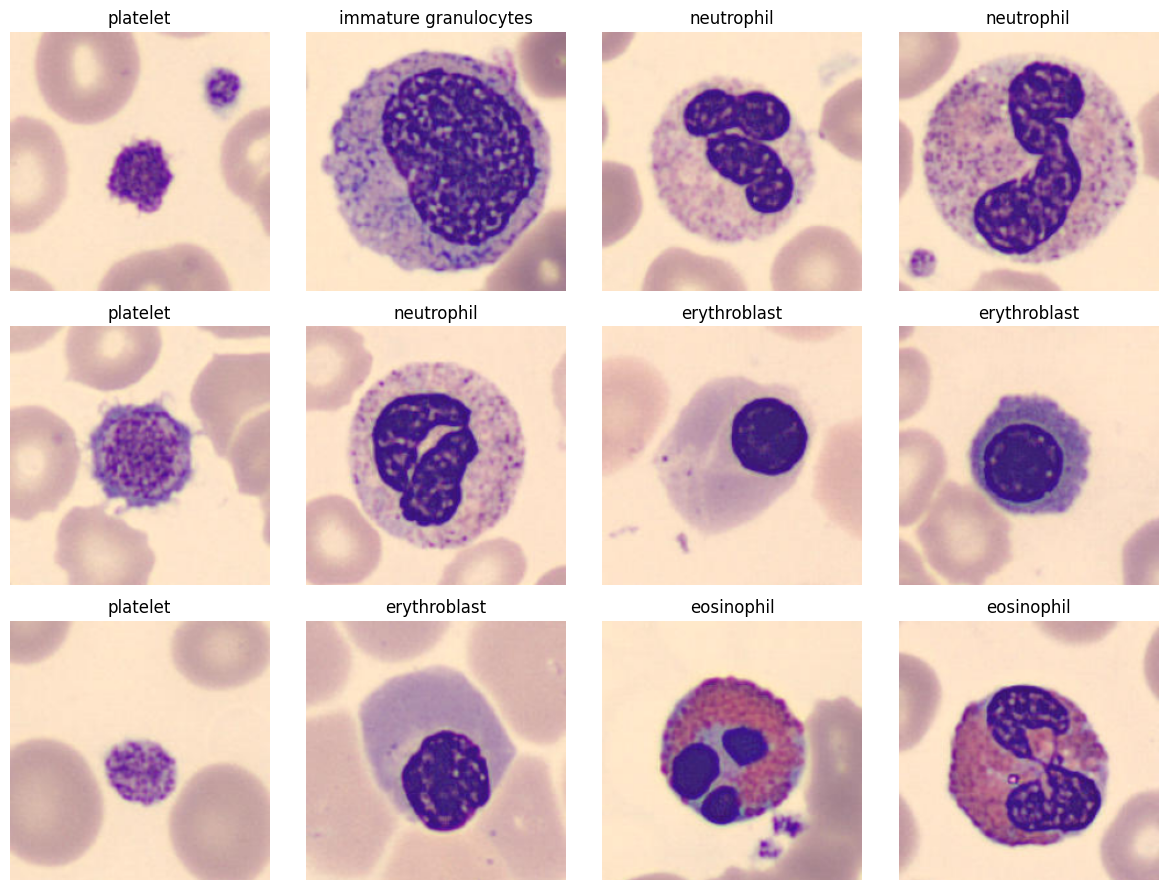

In [ ]:
label_names = {
    0: "basophil",
    1: "eosinophil",
    2: "erythroblast",
    3: "immature granulocytes",
    4: "lymphocyte",
    5: "monocyte",
    6: "neutrophil",
    7: "platelet"
}

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, idx in zip(axes.flatten(), range(12)):
    img, label = train_dataset[idx]
    img = np.array(img)
    ax.imshow(img)
    ax.set_title(label_names[int(label)])
    ax.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_580/731348793.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels = [int(train_dataset[i][1]) for i in range(len(train_dataset))]


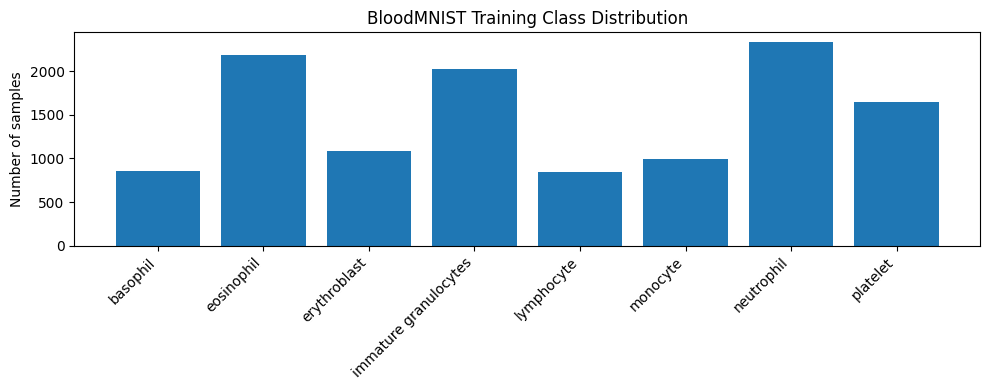

In [ ]:
labels = [int(train_dataset[i][1]) for i in range(len(train_dataset))]
counts = Counter(labels)

plt.figure(figsize=(10, 4))
plt.bar(counts.keys(), counts.values())
plt.xticks(list(counts.keys()), [label_names[k] for k in counts.keys()], rotation=45, ha="right")
plt.ylabel("Number of samples")
plt.title("BloodMNIST Training Class Distribution")
plt.tight_layout()
plt.show()

## Image to Patch Visualization

In [ ]:
stats_transform = transforms.ToTensor()

train_dataset.transform = stats_transform
val_dataset.transform = stats_transform
test_dataset.transform = stats_transform

In [ ]:
stats_batch_size = 32
stats_num_workers = 2

stats_loader = DataLoader(
    train_dataset,
    batch_size=stats_batch_size,
    shuffle=False,
    num_workers=stats_num_workers,
    pin_memory=(device.type == "cuda")
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images, _ in stats_loader:
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sq_sum += (images ** 2).sum(dim=(0, 2, 3))
    num_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / num_pixels
std = torch.sqrt(channel_sq_sum / num_pixels - mean ** 2)

print("Mean :", mean)
print("Std  :", std)

Mean : tensor([0.7961, 0.6596, 0.6964])
Std  : tensor([0.2265, 0.2598, 0.0962])


In [ ]:
final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_dataset.transform = final_transform
val_dataset.transform = final_transform
test_dataset.transform = final_transform

/tmp/ipykernel_9340/3754634410.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[idx].set_title(label_names[int(label)])


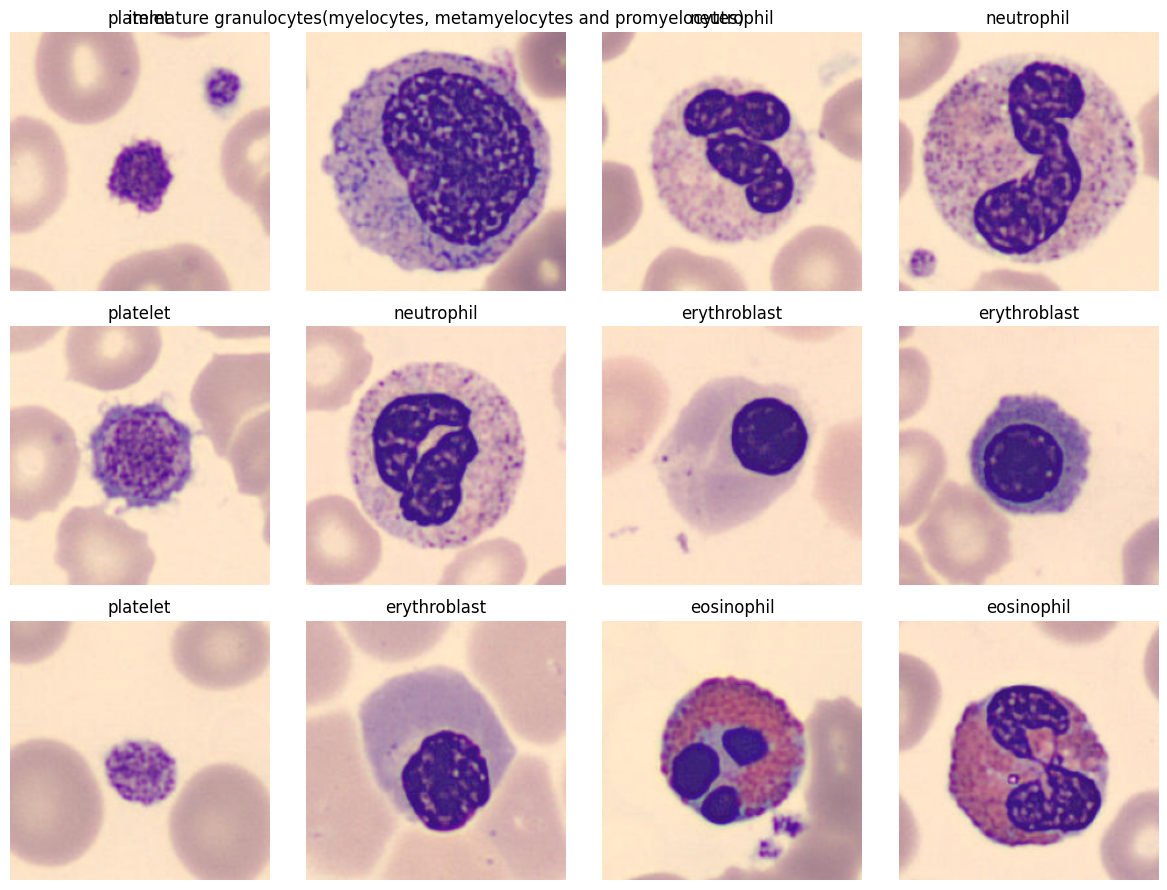

In [ ]:
num_samples_to_show = 12

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for idx in range(num_samples_to_show):
    image, label = train_dataset[idx]

    image = image.permute(1, 2, 0).cpu()
    image = image * std.view(1, 1, 3) + mean.view(1, 1, 3)
    image = torch.clamp(image, 0, 1)

    axes[idx].imshow(image.numpy())
    axes[idx].set_title(label_names[int(label)])
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    random.seed(worker_seed)
    np.random.seed(worker_seed)

In [ ]:
def create_dataloaders(seed: int):
    batch_size = 128
    num_workers = 2

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=g
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )

    return train_loader, val_loader, test_loader

In [ ]:
patch_size = 16
image_size = 224

assert image_size % patch_size == 0, "image_size must be divisible by patch_size"

num_patches_per_side = image_size // patch_size
num_patches = num_patches_per_side * num_patches_per_side
patch_dim = 3 * patch_size * patch_size

print("Patch size         :", patch_size)
print("Num patches/side   :", num_patches_per_side)
print("Total num patches  :", num_patches)
print("Patch dimension    :", patch_dim)

Patch size         : 16
Num patches/side   : 14
Total num patches  : 196
Patch dimension    : 768


In [ ]:
def image_to_patch_sequence(x, patch_size: int):
    """
    x: [B, C, H, W]
    return: [B, num_patches, patch_dim]
    """
    B, C, H, W = x.shape

    patches = x.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.contiguous().permute(0, 2, 3, 1, 4, 5)
    patches = patches.contiguous().view(B, -1, C * patch_size * patch_size)

    return patches

In [ ]:
tmp_loader = DataLoader(train_dataset, batch_size=4, shuffle=False)

images, labels = next(iter(tmp_loader))
seq = image_to_patch_sequence(images, patch_size=patch_size)

print("Image batch shape    :", images.shape)
print("Sequence batch shape :", seq.shape)
print("Label shape          :", labels.shape)

Image batch shape    : torch.Size([4, 3, 224, 224])
Sequence batch shape : torch.Size([4, 196, 768])
Label shape          : torch.Size([4, 1])


In [ ]:
sample_index = 0

image, label = train_dataset[sample_index]

print("Image tensor shape:", image.shape)
print("Label:", int(label))
print("Class name:", label_names[int(label)])

Image tensor shape: torch.Size([3, 224, 224])
Label: 7
Class name: platelet


/tmp/ipykernel_9340/895920010.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Label:", int(label))
/tmp/ipykernel_9340/895920010.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Class name:", label_names[int(label)])


In [ ]:
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: [C, H, W]
    mean, std: torch tensor shape [3]
    """
    img = img_tensor.clone().cpu()
    img = img * std.view(3, 1, 1) + mean.view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    return img

/tmp/ipykernel_9340/3339690763.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Original Image — {label_names[int(label)]}")


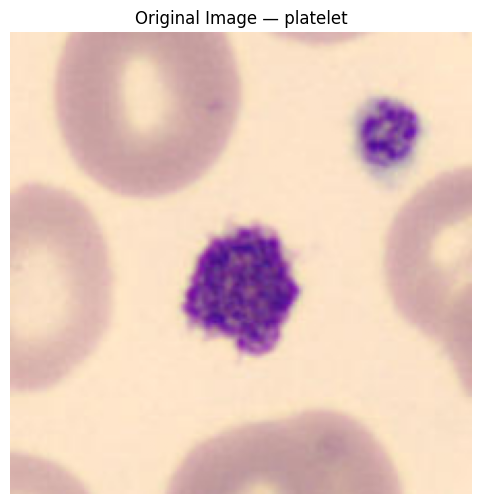

In [ ]:
vis_img = denormalize_image(image, mean, std)
vis_img_np = vis_img.permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(vis_img_np)
plt.title(f"Original Image — {label_names[int(label)]}")
plt.axis("off")
plt.show()

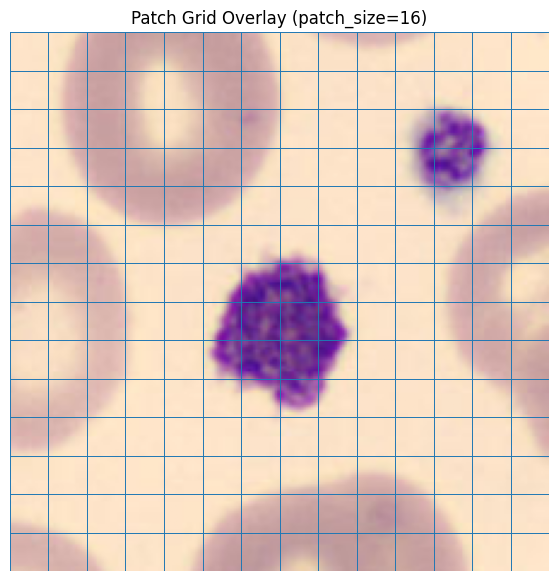

In [ ]:
patch_size = 16

plt.figure(figsize=(7, 7))
plt.imshow(vis_img_np)

H, W = vis_img_np.shape[:2]

for y in range(0, H, patch_size):
    plt.axhline(y - 0.5, linewidth=0.7)

for x in range(0, W, patch_size):
    plt.axvline(x - 0.5, linewidth=0.7)

plt.title(f"Patch Grid Overlay (patch_size={patch_size})")
plt.axis("off")
plt.show()

In [ ]:
single_image = image.unsqueeze(0)  # [1, C, H, W]
single_seq = image_to_patch_sequence(single_image, patch_size=patch_size)

print("Single image shape :", single_image.shape)
print("Patch sequence shape:", single_seq.shape)

Single image shape : torch.Size([1, 3, 224, 224])
Patch sequence shape: torch.Size([1, 196, 768])


In [ ]:
num_show = 16  # tampilkan 16 patch pertama

patches = single_seq[0][:num_show]  # [num_show, patch_dim]
patches = patches.view(num_show, 3, patch_size, patch_size)

patches_vis = []
for p in patches:
    p = denormalize_image(p, mean, std)
    p = p.permute(1, 2, 0).numpy()
    patches_vis.append(p)

print("Patch tensor shape:", patches.shape)

Patch tensor shape: torch.Size([16, 3, 16, 16])


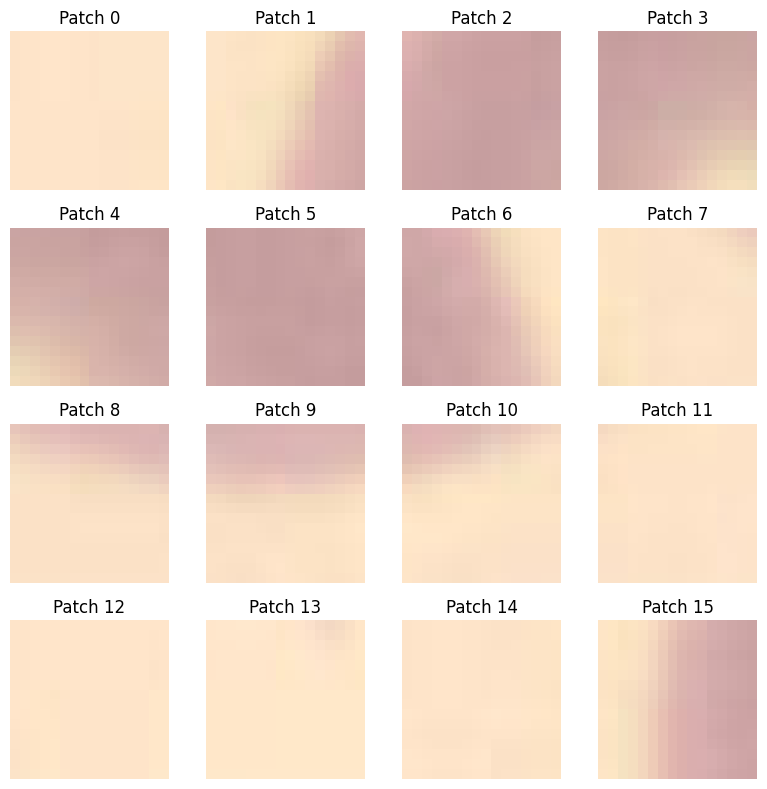

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()

for i in range(num_show):
    axes[i].imshow(patches_vis[i])
    axes[i].set_title(f"Patch {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

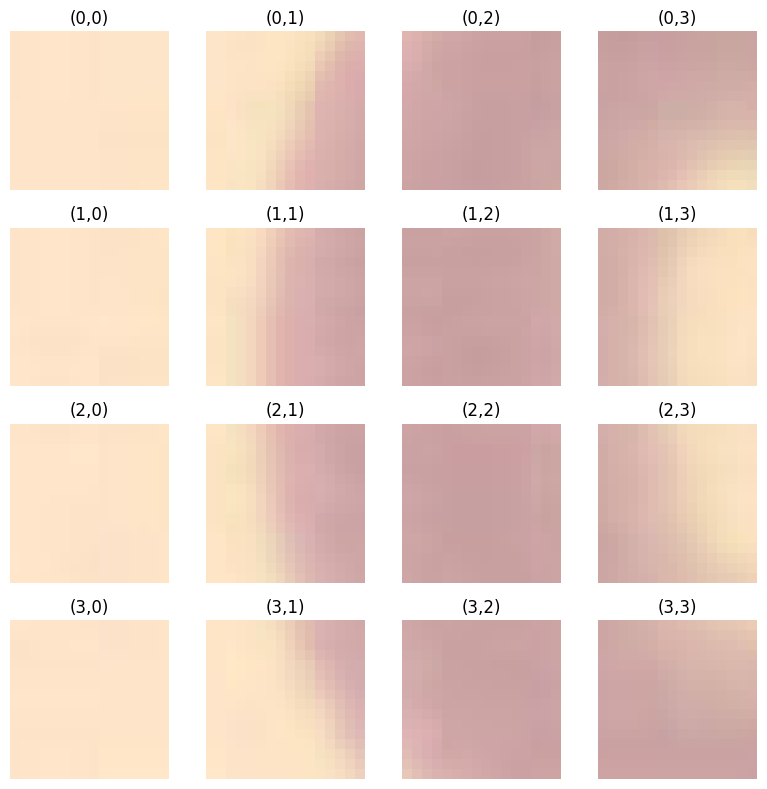

In [ ]:
all_patches = single_seq[0]  # [196, 768]
all_patches = all_patches.view(num_patches_per_side, num_patches_per_side, 3, patch_size, patch_size)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for r in range(4):
    for c in range(4):
        patch = all_patches[r, c]
        patch = denormalize_image(patch, mean, std)
        patch = patch.permute(1, 2, 0).numpy()

        axes[r, c].imshow(patch)
        axes[r, c].set_title(f"({r},{c})")
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def reconstruct_from_patch_sequence(seq, patch_size, image_size):
    """
    seq: [num_patches, patch_dim]
    return: [3, H, W]
    """
    num_patches_per_side = image_size // patch_size

    patches = seq.view(
        num_patches_per_side,
        num_patches_per_side,
        3,
        patch_size,
        patch_size
    )

    patches = patches.permute(2, 0, 3, 1, 4).contiguous()
    reconstructed = patches.view(3, image_size, image_size)

    return reconstructed

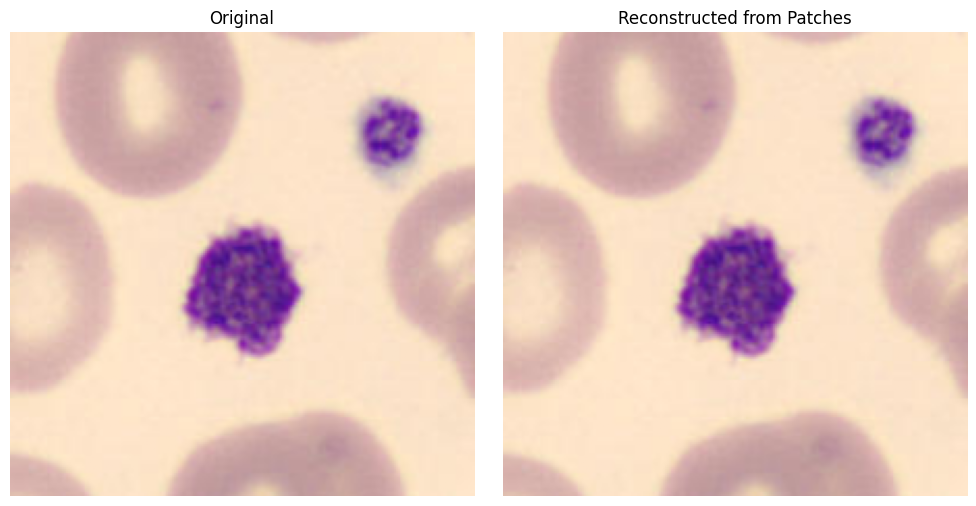

In [ ]:
reconstructed = reconstruct_from_patch_sequence(
    seq=single_seq[0],
    patch_size=patch_size,
    image_size=image_size
)

orig_vis = denormalize_image(image, mean, std).permute(1, 2, 0).numpy()
recon_vis = denormalize_image(reconstructed, mean, std).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(orig_vis)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(recon_vis)
axes[1].set_title("Reconstructed from Patches")
axes[1].axis("off")

plt.tight_layout()
plt.show()

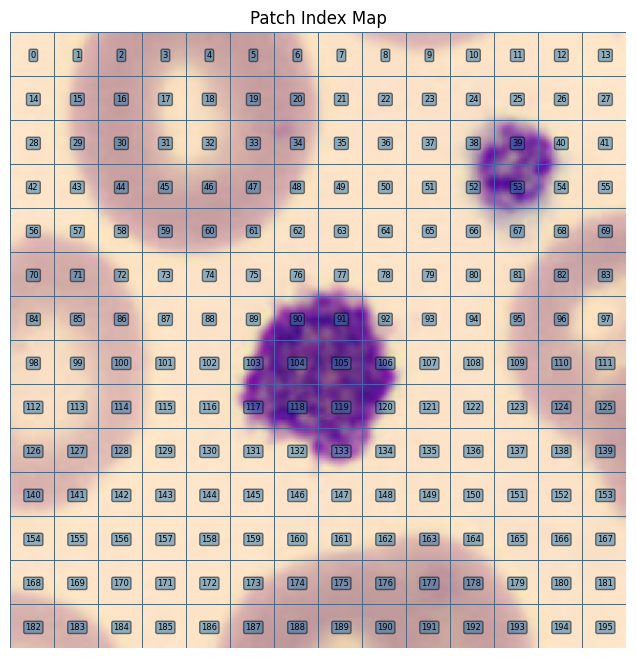

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(vis_img_np)

idx = 0
for r in range(num_patches_per_side):
    for c in range(num_patches_per_side):
        y = r * patch_size
        x = c * patch_size

        plt.axhline(y - 0.5, linewidth=0.5)
        plt.axvline(x - 0.5, linewidth=0.5)

        plt.text(
            x + patch_size / 2,
            y + patch_size / 2,
            str(idx),
            ha="center",
            va="center",
            fontsize=6,
            bbox=dict(boxstyle="round,pad=0.2", alpha=0.5)
        )
        idx += 1

plt.title("Patch Index Map")
plt.axis("off")
plt.show()

## Preprocess

In [ ]:
stats_transform = transforms.ToTensor()

train_dataset.transform = stats_transform
val_dataset.transform = stats_transform
test_dataset.transform = stats_transform

In [ ]:
stats_batch_size = 32
stats_num_workers = 2

stats_loader = DataLoader(
    train_dataset,
    batch_size=stats_batch_size,
    shuffle=False,
    num_workers=stats_num_workers,
    pin_memory=(device.type == "cuda")
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images, _ in stats_loader:
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sq_sum += (images ** 2).sum(dim=(0, 2, 3))
    num_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / num_pixels
std = torch.sqrt(channel_sq_sum / num_pixels - mean ** 2)

print("Mean :", mean)
print("Std  :", std)

Mean : tensor([0.7961, 0.6596, 0.6964])
Std  : tensor([0.2265, 0.2598, 0.0962])


In [ ]:
final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_dataset.transform = final_transform
val_dataset.transform = final_transform
test_dataset.transform = final_transform

/tmp/ipykernel_2883/3754634410.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[idx].set_title(label_names[int(label)])


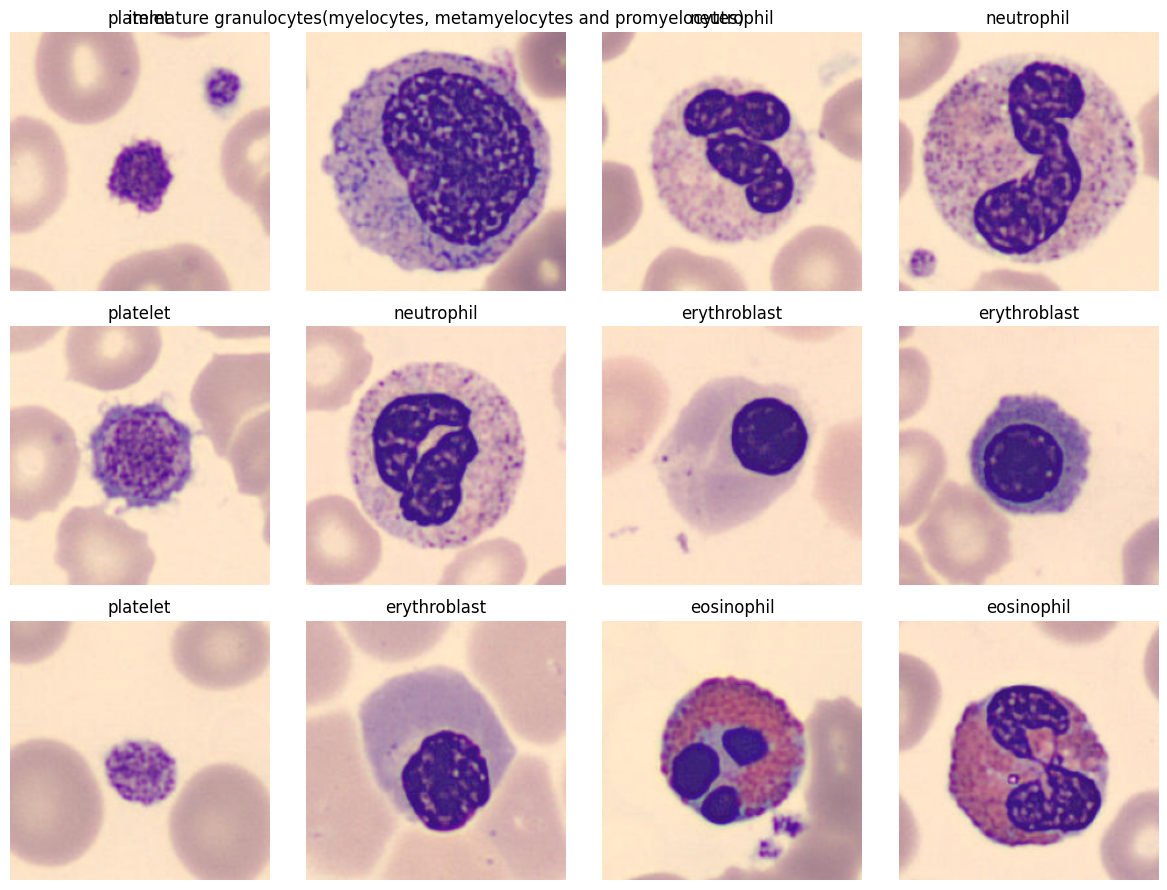

In [ ]:
num_samples_to_show = 12

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for idx in range(num_samples_to_show):
    image, label = train_dataset[idx]

    image = image.permute(1, 2, 0).cpu()
    image = image * std.view(1, 1, 3) + mean.view(1, 1, 3)
    image = torch.clamp(image, 0, 1)

    axes[idx].imshow(image.numpy())
    axes[idx].set_title(label_names[int(label)])
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    random.seed(worker_seed)
    np.random.seed(worker_seed)

In [ ]:
def create_dataloaders(seed: int):
    batch_size = 256
    num_workers = 2

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=g
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )

    return train_loader, val_loader, test_loader

In [ ]:
patch_size = 16
image_size = 224

assert image_size % patch_size == 0, "image_size must be divisible by patch_size"

# num_patches_per_side = image_size // patch_size
# num_patches = num_patches_per_side * num_patches_per_side
# patch_dim = 3 * patch_size * patch_size

num_patches_per_side = image_size // patch_size
grid_h = num_patches_per_side
grid_w = num_patches_per_side
num_patches = grid_h * grid_w
patch_dim = 3 * patch_size * patch_size

print("Patch size         :", patch_size)
print("Num patches/side   :", num_patches_per_side)
print("Grid H x W         :", grid_h, "x", grid_w)
print("Total num patches  :", num_patches)
print("Patch dimension    :", patch_dim)

Patch size         : 16
Num patches/side   : 14
Grid H x W         : 14 x 14
Total num patches  : 196
Patch dimension    : 768


In [ ]:
def image_to_patch_sequence(x, patch_size: int):
    """
    x: [B, C, H, W]
    return: [B, num_patches, patch_dim]
    """
    B, C, H, W = x.shape

    patches = x.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.contiguous().permute(0, 2, 3, 1, 4, 5)
    patches = patches.contiguous().view(B, -1, C * patch_size * patch_size)

    return patches

In [ ]:
tmp_loader = DataLoader(train_dataset, batch_size=4, shuffle=False)

images, labels = next(iter(tmp_loader))
seq = image_to_patch_sequence(images, patch_size=patch_size)

print("Image batch shape    :", images.shape)
print("Sequence batch shape :", seq.shape)
print("Label shape          :", labels.shape)

Image batch shape    : torch.Size([4, 3, 224, 224])
Sequence batch shape : torch.Size([4, 196, 768])
Label shape          : torch.Size([4, 1])


## Modelling and Training (w/ Patch-wise only)

In [ ]:
num_classes = len(label_names)

input_size = patch_dim
hidden_size = 256
num_layers = 3
recurrent_dropout = 0.3
head_dropout = 0.3

print("Input size  :", input_size)
print("Hidden size :", hidden_size)
print("Num layers  :", num_layers)
print("Classes     :", num_classes)

Input size  : 768
Hidden size : 256
Num layers  : 3
Classes     : 8


### Architecture Defined

In [ ]:
class RecurrentClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_classes: int,
        architecture: str,
        num_layers: int = 2,
        recurrent_dropout: float = 0.0,
        head_dropout: float = 0.0
    ):
        super().__init__()

        self.architecture = architecture.lower()

        if self.architecture == "rnn":
            self.bidirectional = False
            self.recurrent = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False,
                nonlinearity="tanh"
            )

        elif self.architecture == "lstm":
            self.bidirectional = False
            self.recurrent = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False
            )

        elif self.architecture == "bilstm":
            self.bidirectional = True
            self.recurrent = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=True
            )

        elif self.architecture == "gru":
            self.bidirectional = False
            self.recurrent = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False
            )

        elif self.architecture == "bigru":
            self.bidirectional = True
            self.recurrent = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=True
            )

        else:
            raise ValueError("architecture must be one of: rnn, lstm, bilstm, gru, bigru")

        direction_factor = 2 if self.bidirectional else 1
        final_dim = hidden_size * direction_factor

        self.norm = nn.LayerNorm(final_dim)
        self.dropout = nn.Dropout(head_dropout)
        self.classifier = nn.Linear(final_dim, num_classes)

    def forward(self, x):
        if self.architecture in ["lstm", "bilstm"]:
            output, (h_n, c_n) = self.recurrent(x)
        else:
            output, h_n = self.recurrent(x)

        if self.bidirectional:
            last_forward = h_n[-2]
            last_backward = h_n[-1]
            final_feature = torch.cat([last_forward, last_backward], dim=1)
        else:
            final_feature = h_n[-1]

        final_feature = self.norm(final_feature)
        final_feature = self.dropout(final_feature)
        logits = self.classifier(final_feature)

        return logits

In [ ]:
def build_model(architecture: str):
    model = RecurrentClassifier(
        input_size=input_size,
        hidden_size=hidden_size,
        num_classes=num_classes,
        architecture=architecture,
        num_layers=num_layers,
        recurrent_dropout=recurrent_dropout,
        head_dropout=head_dropout
    )
    return model.to(device)

### Training

In [ ]:
max_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4
early_stopping_patience = 3

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            seq = image_to_patch_sequence(images, patch_size=patch_size)
            logits = model(seq)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_f1

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            seq = image_to_patch_sequence(images, patch_size=patch_size)
            logits = model(seq)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "macro_f1": epoch_f1,
        "macro_precision": epoch_precision,
        "macro_recall": epoch_recall,
        "y_true": all_targets,
        "y_pred": all_preds
    }

In [ ]:
def fit_one_seed(architecture: str, seed: int):
    seed_everything(seed)

    train_loader, val_loader, test_loader = create_dataloaders(seed=seed)

    model = build_model(architecture=architecture)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    patience_counter = 0

    history = []

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler
        )

        val_metrics = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_macro_f1": val_metrics["macro_f1"]
        }
        history.append(row)

        print(
            f"[INFO] [{architecture.upper()} | seed={seed} | epoch={epoch:02d}] "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | train_f1={train_f1:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | val_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"[STOP] Early stopping triggered for {architecture} with seed {seed}.")
            break

    total_train_time = time.time() - start_time

    model.load_state_dict(best_state)

    test_metrics = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion
    )

    result = {
        "architecture": architecture,
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "train_time_sec": total_train_time
    }

    history_df = pd.DataFrame(history)

    output_bundle = {
        "y_true": test_metrics["y_true"],
        "y_pred": test_metrics["y_pred"],
        "history": history_df
    }

    return result, output_bundle

In [ ]:
architectures = ["rnn", "lstm", "bilstm", "gru", "bigru"]
seeds = [13, 27, 42, 123, 3407]

print("Architectures :", architectures)
print("Seeds         :", seeds)
print("Total runs    :", len(architectures) * len(seeds))

Architectures : ['rnn', 'lstm', 'bilstm', 'gru', 'bigru']
Seeds         : [13, 27, 42, 123, 3407]
Total runs    : 25


In [ ]:
all_results = []
all_outputs = {}

for architecture in architectures:
    print("\n" + "=" * 80)
    print(f"Running architecture: {architecture.upper()}")
    print("=" * 80)

    for seed in seeds:
        result, output_bundle = fit_one_seed(architecture=architecture, seed=seed)

        all_results.append(result)
        all_outputs[(architecture, seed)] = output_bundle
        print(f"[INFO] SEED {seed} DONE.")


Running architecture: RNN
[INFO] [RNN | seed=13 | epoch=01] train_loss=2.0973 | train_acc=0.1927 | train_f1=0.1379 | val_loss=1.9730 | val_acc=0.2085 | val_f1=0.1046
[INFO] [RNN | seed=13 | epoch=02] train_loss=1.9930 | train_acc=0.2158 | train_f1=0.1623 | val_loss=1.9354 | val_acc=0.2354 | val_f1=0.1441
[INFO] [RNN | seed=13 | epoch=03] train_loss=1.9642 | train_acc=0.2394 | train_f1=0.1770 | val_loss=1.9144 | val_acc=0.2699 | val_f1=0.1702
[INFO] [RNN | seed=13 | epoch=04] train_loss=1.9327 | train_acc=0.2657 | train_f1=0.1952 | val_loss=1.9345 | val_acc=0.2553 | val_f1=0.1805
[INFO] [RNN | seed=13 | epoch=05] train_loss=1.8836 | train_acc=0.2820 | train_f1=0.2127 | val_loss=1.8817 | val_acc=0.2938 | val_f1=0.2101
[INFO] [RNN | seed=13 | epoch=06] train_loss=1.8448 | train_acc=0.2975 | train_f1=0.2270 | val_loss=1.8135 | val_acc=0.3236 | val_f1=0.2313
[INFO] [RNN | seed=13 | epoch=07] train_loss=1.8402 | train_acc=0.3055 | train_f1=0.2298 | val_loss=1.8356 | val_acc=0.3032 | val_f1=

### Evaluation Result

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["architecture", "seed"]).reset_index(drop=True)

results_df

,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,bigru,13,10,0.945708,0.143704,0.950892,0.946238,0.948168,0.944649,242.277447
1,bigru,27,7,0.934312,0.172945,0.940953,0.935091,0.934525,0.936074,185.822326
2,bigru,42,10,0.946748,0.158063,0.943876,0.936062,0.941135,0.931818,242.248196
3,bigru,123,11,0.952762,0.125772,0.955861,0.952431,0.953201,0.951837,261.178050
4,bigru,3407,9,0.946814,0.163398,0.940953,0.935126,0.944090,0.928411,226.254568
5,bilstm,13,22,0.927184,0.216401,0.928384,0.919114,0.920968,0.921244,477.434460
6,bilstm,27,15,0.920224,0.216747,0.927214,0.918294,0.917173,0.919821,342.593213
7,bilstm,42,12,0.915190,0.235090,0.923122,0.914124,0.915590,0.913229,283.037825
8,bilstm,123,17,0.931126,0.191731,0.936276,0.926109,0.931808,0.922437,376.563601
9,bilstm,3407,14,0.921279,0.207406,0.930430,0.921877,0.921204,0.923319,320.657841


In [ ]:
summary_df = (
    results_df
    .groupby("architecture", as_index=False)
    .agg(
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),
        test_precision_mean=("test_macro_precision", "mean"),
        test_precision_std=("test_macro_precision", "std"),
        test_recall_mean=("test_macro_recall", "mean"),
        test_recall_std=("test_macro_recall", "std"),
        best_val_f1_mean=("best_val_f1", "mean"),
        best_val_f1_std=("best_val_f1", "std"),
        train_time_mean_sec=("train_time_sec", "mean"),
        best_epoch_mean=("best_epoch", "mean")
    )
    .sort_values("test_macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

summary_df

,architecture,test_acc_mean,test_acc_std,test_macro_f1_mean,test_macro_f1_std,test_precision_mean,test_precision_std,test_recall_mean,test_recall_std,best_val_f1_mean,best_val_f1_std,train_time_mean_sec,best_epoch_mean
0,bigru,0.946507,0.006621,0.940989,0.007936,0.944224,0.007067,0.938558,0.009591,0.945269,0.006726,231.556117,9.4
1,gru,0.945688,0.010447,0.940041,0.012089,0.942348,0.013630,0.938914,0.011601,0.945181,0.013597,300.783452,13.2
2,bilstm,0.929085,0.004824,0.919904,0.004445,0.921348,0.006328,0.920010,0.004012,0.923001,0.006229,360.057388,16.0
3,lstm,0.896229,0.036696,0.883451,0.043209,0.888127,0.041360,0.881687,0.043069,0.890753,0.045142,319.793605,14.0
4,rnn,0.306051,0.034696,0.222507,0.033258,0.285708,0.044761,0.250947,0.033420,0.222576,0.030548,151.599780,5.2


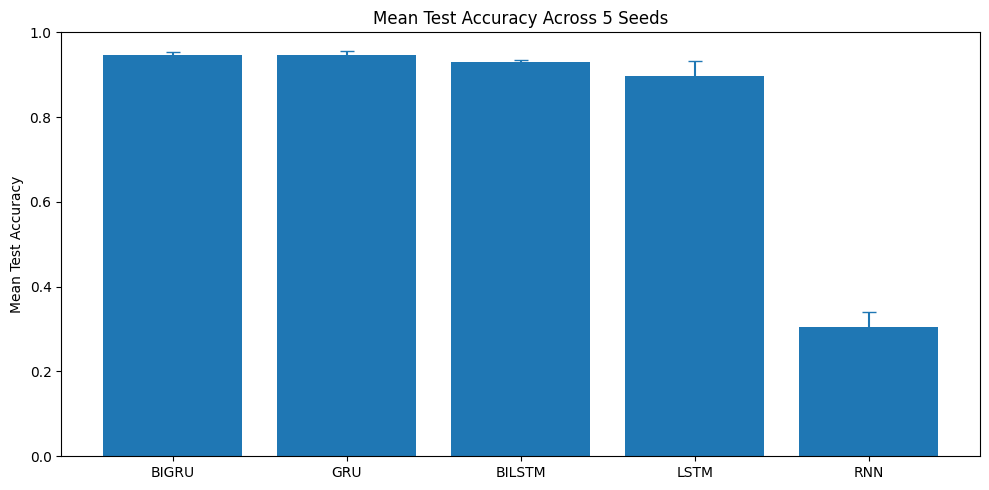

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(summary_df))
y = summary_df["test_acc_mean"].values
yerr = summary_df["test_acc_std"].fillna(0).values

plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)

plt.xticks(x, summary_df["architecture"].str.upper())
plt.ylabel("Mean Test Accuracy")
plt.title("Mean Test Accuracy Across 5 Seeds")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

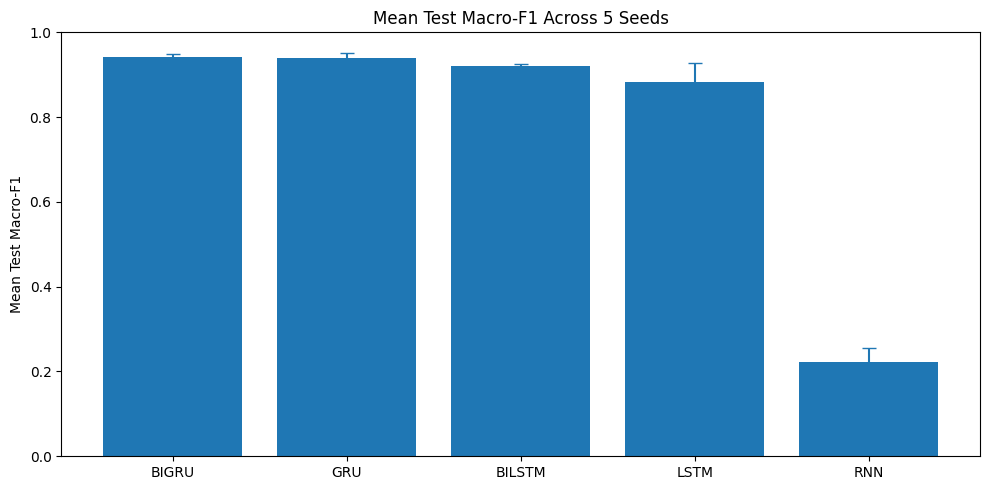

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(summary_df))
y = summary_df["test_macro_f1_mean"].values
yerr = summary_df["test_macro_f1_std"].fillna(0).values

plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)

plt.xticks(x, summary_df["architecture"].str.upper())
plt.ylabel("Mean Test Macro-F1")
plt.title("Mean Test Macro-F1 Across 5 Seeds")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
results_df.sort_values(["test_macro_f1", "test_acc"], ascending=False)

,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
3,bigru,123,11,0.952762,0.125772,0.955861,0.952431,0.953201,0.951837,261.178050
11,gru,27,20,0.960305,0.142641,0.954692,0.951003,0.952723,0.949475,421.953856
13,gru,123,14,0.951883,0.139042,0.951476,0.947493,0.949667,0.946513,311.393945
0,bigru,13,10,0.945708,0.143704,0.950892,0.946238,0.948168,0.944649,242.277447
14,gru,3407,16,0.946347,0.150505,0.949138,0.942150,0.951154,0.935913,365.899262
10,gru,13,10,0.943690,0.158193,0.945045,0.939625,0.937852,0.942405,238.674683
2,bigru,42,10,0.946748,0.158063,0.943876,0.936062,0.941135,0.931818,242.248196
4,bigru,3407,9,0.946814,0.163398,0.940953,0.935126,0.944090,0.928411,226.254568
1,bigru,27,7,0.934312,0.172945,0.940953,0.935091,0.934525,0.936074,185.822326
8,bilstm,123,17,0.931126,0.191731,0.936276,0.926109,0.931808,0.922437,376.563601


### Single Run Check

In [ ]:
best_runs_per_arch = (
    results_df
    .sort_values(["architecture", "test_macro_f1", "test_acc"], ascending=[True, False, False])
    .groupby("architecture", as_index=False)
    .first()
    .sort_values("architecture")
    .reset_index(drop=True)
)

print("Best seed for each architecture")
best_runs_per_arch

Best seed for each architecture


,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,bigru,123,11,0.952762,0.125772,0.955861,0.952431,0.953201,0.951837,261.178050
1,bilstm,123,17,0.931126,0.191731,0.936276,0.926109,0.931808,0.922437,376.563601
2,gru,27,20,0.960305,0.142641,0.954692,0.951003,0.952723,0.949475,421.953856
3,lstm,42,19,0.928573,0.202069,0.929260,0.922425,0.924698,0.921628,414.886002
4,rnn,13,10,0.266283,1.714590,0.359252,0.274801,0.318063,0.303724,246.417850


In [ ]:
summary_best_only = best_runs_per_arch[
    [
        "architecture",
        "seed",
        "best_epoch",
        "best_val_f1",
        "test_acc",
        "test_macro_f1",
        "test_macro_precision",
        "test_macro_recall",
        "train_time_sec"
    ]
].copy()

summary_best_only["architecture"] = summary_best_only["architecture"].str.upper()
summary_best_only

,architecture,seed,best_epoch,best_val_f1,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,BIGRU,123,11,0.952762,0.955861,0.952431,0.953201,0.951837,261.178050
1,BILSTM,123,17,0.931126,0.936276,0.926109,0.931808,0.922437,376.563601
2,GRU,27,20,0.960305,0.954692,0.951003,0.952723,0.949475,421.953856
3,LSTM,42,19,0.928573,0.929260,0.922425,0.924698,0.921628,414.886002
4,RNN,13,10,0.266283,0.359252,0.274801,0.318063,0.303724,246.417850


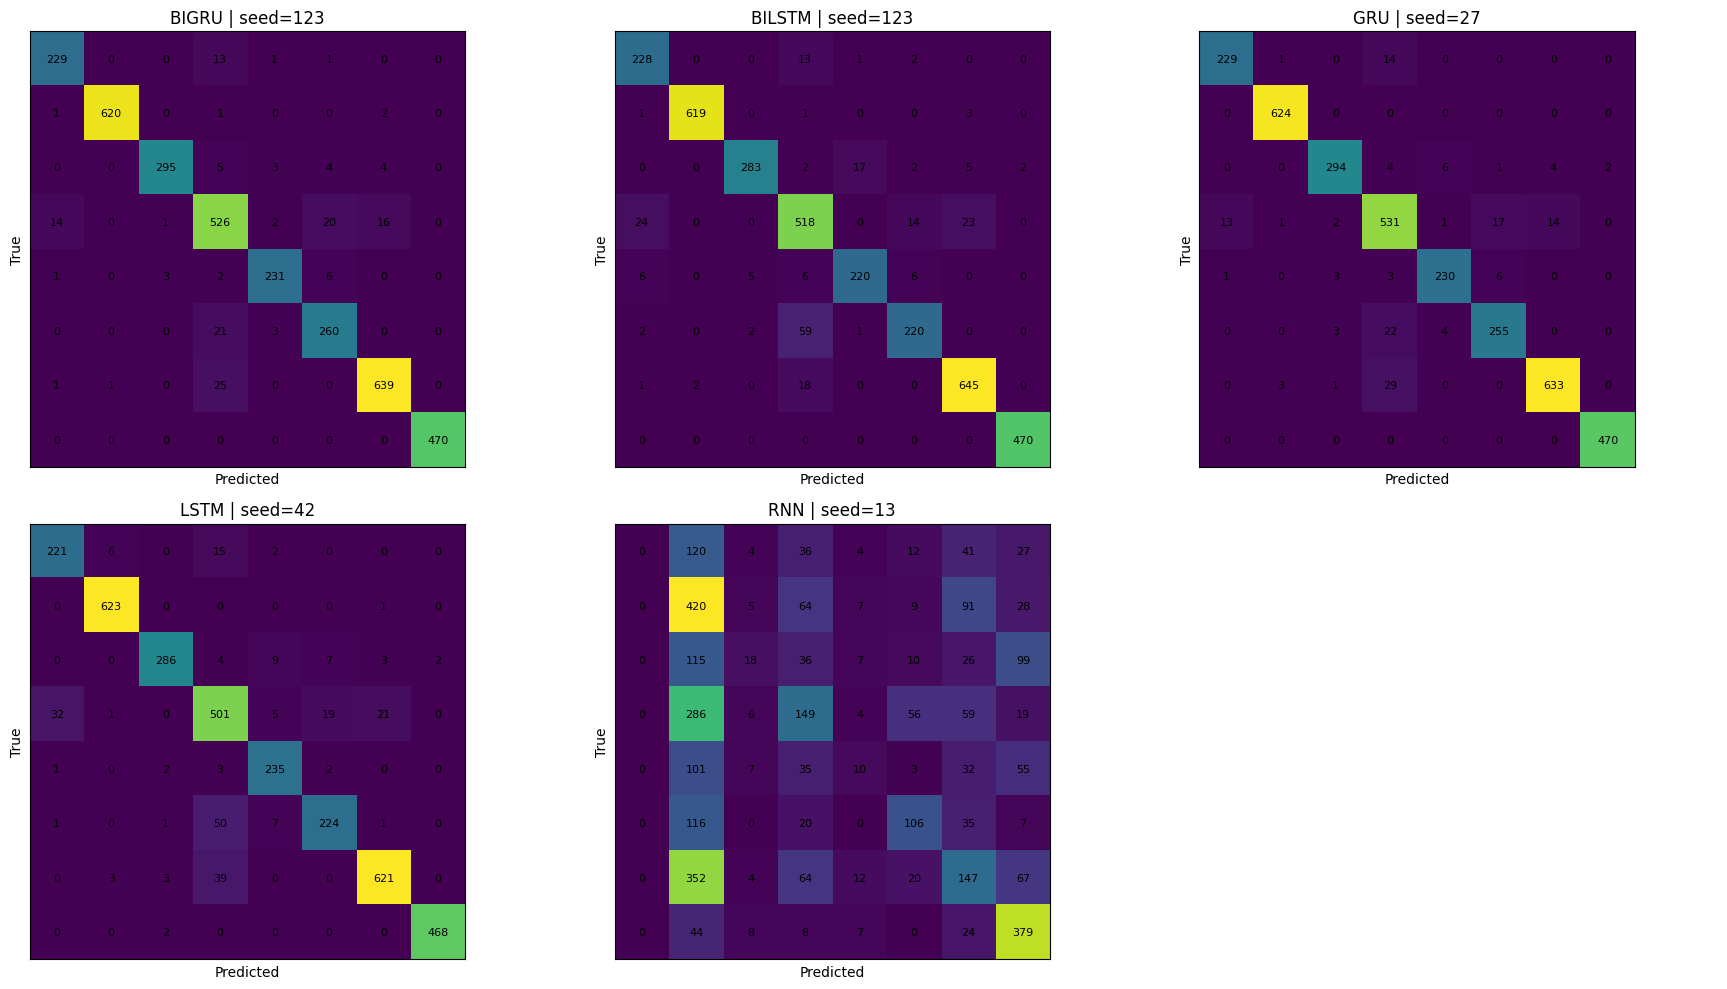

In [ ]:
import math

arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    output = all_outputs[(architecture, seed)]
    y_true = output["y_true"]
    y_pred = output["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    im = ax.imshow(cm)
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # ax.set_xticks(np.arange(len(label_names)))
    # ax.set_yticks(np.arange(len(label_names)))
    # ax.set_xticklabels([label_names[i] for i in range(len(label_names))], rotation=45, ha="right")
    # ax.set_yticklabels([label_names[i] for i in range(len(label_names))])

    ax.set_xticks([])
    ax.set_yticks([])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

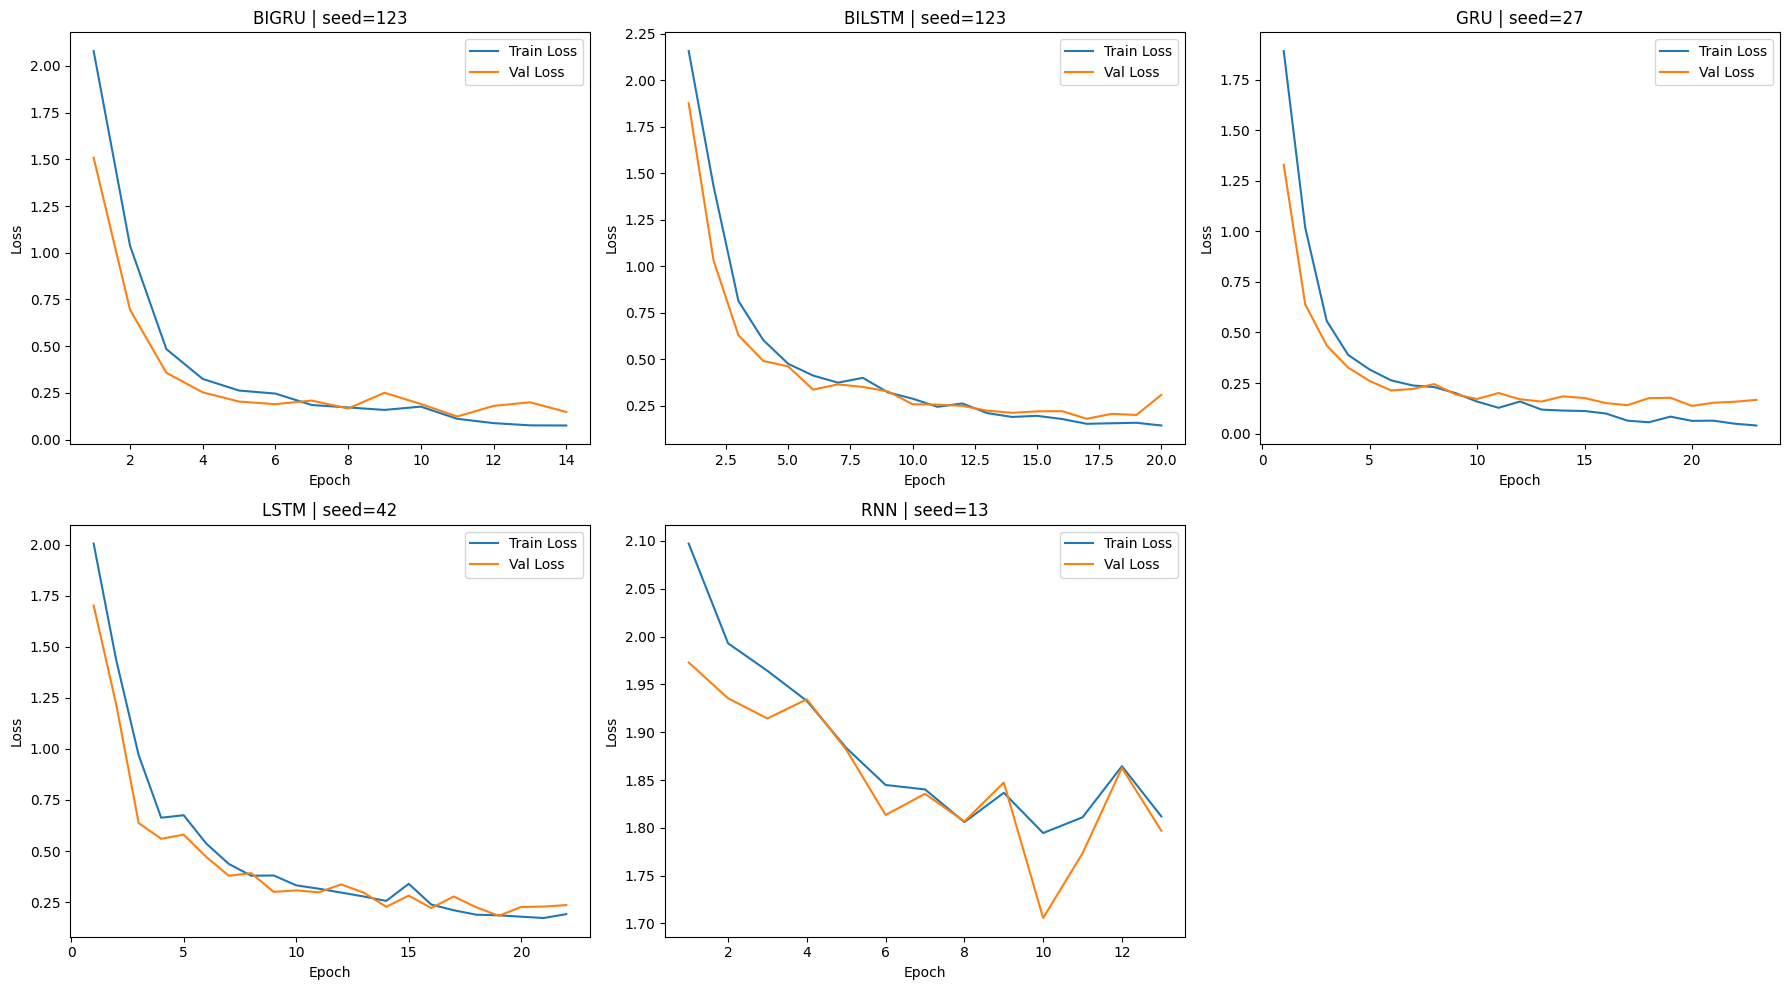

In [ ]:
arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    history = all_outputs[(architecture, seed)]["history"]

    ax.plot(history["epoch"], history["train_loss"], label="Train Loss")
    ax.plot(history["epoch"], history["val_loss"], label="Val Loss")
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

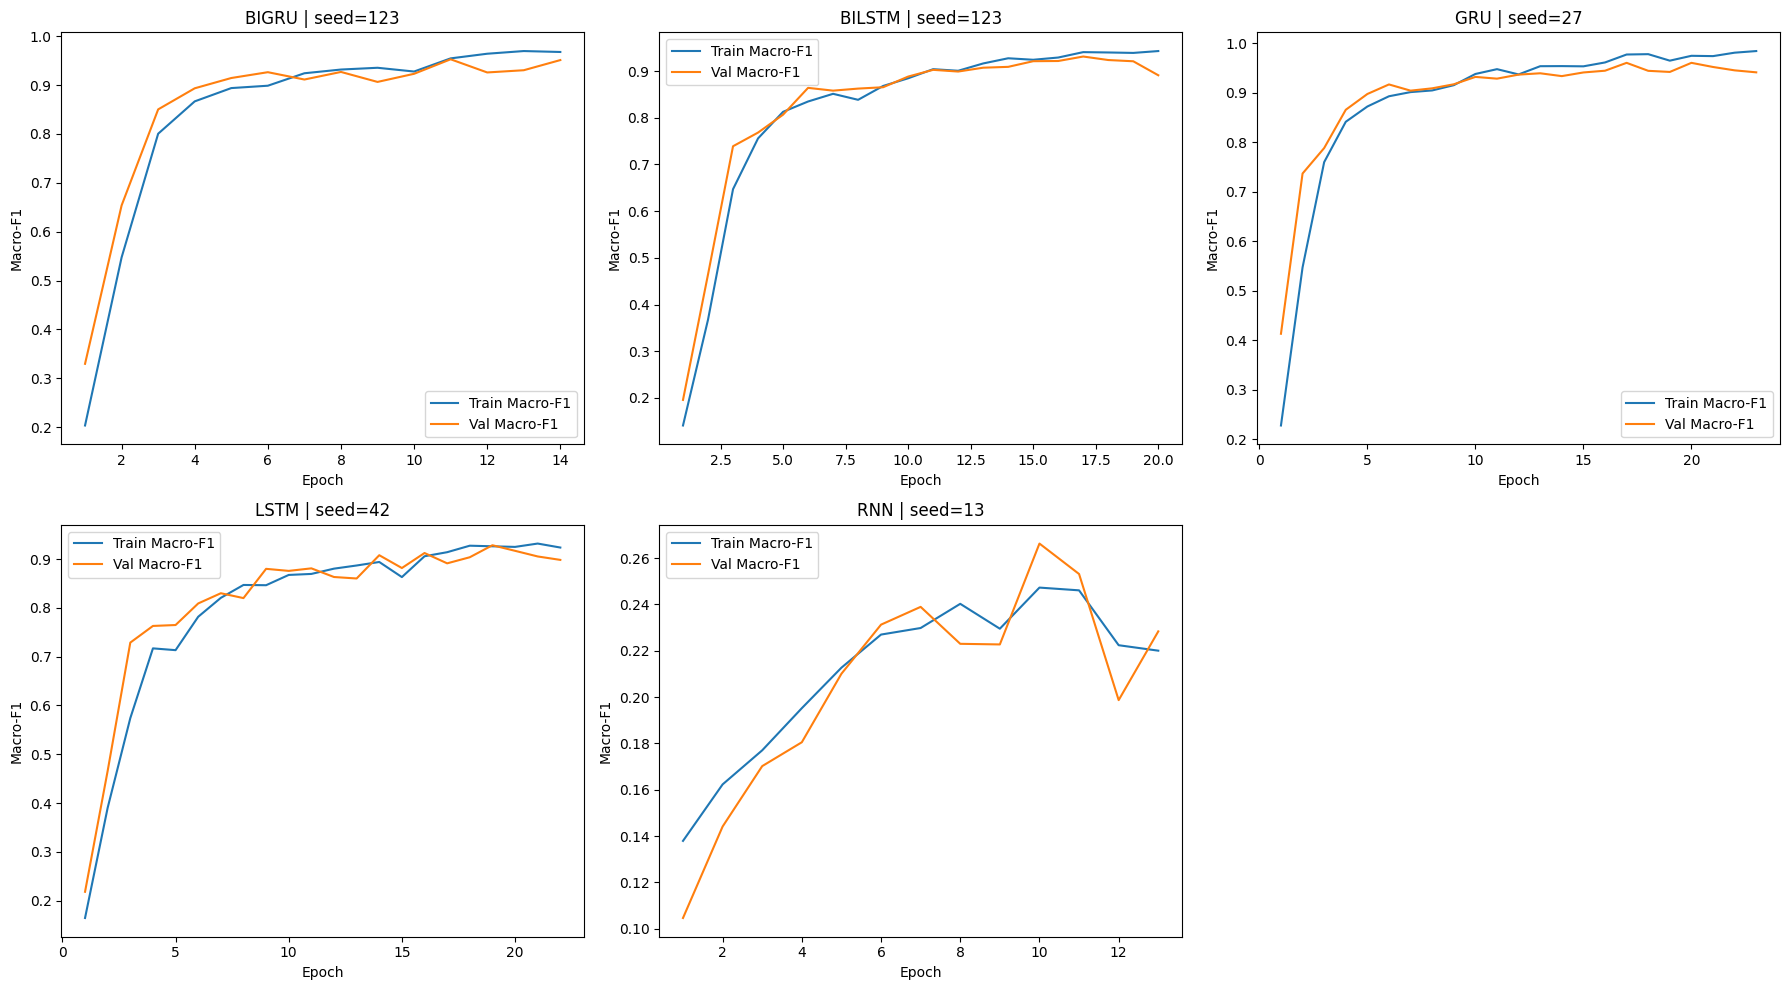

In [ ]:
arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    history = all_outputs[(architecture, seed)]["history"]

    ax.plot(history["epoch"], history["train_macro_f1"], label="Train Macro-F1")
    ax.plot(history["epoch"], history["val_macro_f1"], label="Val Macro-F1")
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro-F1")
    ax.legend()

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
best_visual_summary = best_runs_per_arch.copy()
best_visual_summary["architecture"] = best_visual_summary["architecture"].str.upper()

best_visual_summary = best_visual_summary[
    [
        "architecture",
        "seed",
        "best_epoch",
        "test_acc",
        "test_macro_f1",
        "test_macro_precision",
        "test_macro_recall"
    ]
].sort_values("test_macro_f1", ascending=False)

best_visual_summary

,architecture,seed,best_epoch,test_acc,test_macro_f1,test_macro_precision,test_macro_recall
0,BIGRU,123,11,0.955861,0.952431,0.953201,0.951837
2,GRU,27,20,0.954692,0.951003,0.952723,0.949475
1,BILSTM,123,17,0.936276,0.926109,0.931808,0.922437
3,LSTM,42,19,0.929260,0.922425,0.924698,0.921628
4,RNN,13,10,0.359252,0.274801,0.318063,0.303724


## Modelling and Training (w/ 1D Positional Encoding)

In [ ]:
num_classes = len(label_names)

patch_dim = 3 * patch_size * patch_size
embed_dim = 256
hidden_size = 256
num_layers = 3
recurrent_dropout = 0.3
head_dropout = 0.3
use_positional_embedding = True

print("Patch dim   :", patch_dim)
print("Embed dim   :", embed_dim)
print("Hidden size :", hidden_size)
print("Num layers  :", num_layers)
print("Classes     :", num_classes)
print("Use 1D PE   :", use_positional_embedding)

Patch dim   : 768
Embed dim   : 256
Hidden size : 256
Num layers  : 3
Classes     : 8
Use 1D PE   : True


### Architecture Defined

In [ ]:
class RecurrentClassifier(nn.Module):
    def __init__(
        self,
        patch_dim: int,
        embed_dim: int,
        hidden_size: int,
        num_classes: int,
        architecture: str,
        num_patches: int,
        num_layers: int = 2,
        recurrent_dropout: float = 0.0,
        head_dropout: float = 0.0,
        use_positional_embedding: bool = True
    ):
        super().__init__()

        self.architecture = architecture.lower()
        self.use_positional_embedding = use_positional_embedding
        self.num_patches = num_patches
        self.embed_dim = embed_dim

        # Patch projection: raw patch vector -> token embedding
        self.patch_projection = nn.Linear(patch_dim, embed_dim)

        # Learnable 1D positional embedding
        if self.use_positional_embedding:
            self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        else:
            self.pos_embedding = None

        if self.architecture == "rnn":
            self.bidirectional = False
            self.recurrent = nn.RNN(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False,
                nonlinearity="tanh"
            )

        elif self.architecture == "lstm":
            self.bidirectional = False
            self.recurrent = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False
            )

        elif self.architecture == "bilstm":
            self.bidirectional = True
            self.recurrent = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=True
            )

        elif self.architecture == "gru":
            self.bidirectional = False
            self.recurrent = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False
            )

        elif self.architecture == "bigru":
            self.bidirectional = True
            self.recurrent = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=True
            )

        else:
            raise ValueError("architecture must be one of: rnn, lstm, bilstm, gru, bigru")

        direction_factor = 2 if self.bidirectional else 1
        final_dim = hidden_size * direction_factor

        self.norm = nn.LayerNorm(final_dim)
        self.dropout = nn.Dropout(head_dropout)
        self.classifier = nn.Linear(final_dim, num_classes)

    def forward(self, x):
        """
        x: [B, num_patches, patch_dim]
        """
        x = self.patch_projection(x)  # [B, num_patches, embed_dim]

        if self.use_positional_embedding:
            x = x + self.pos_embedding

        if self.architecture in ["lstm", "bilstm"]:
            output, (h_n, c_n) = self.recurrent(x)
        else:
            output, h_n = self.recurrent(x)

        if self.bidirectional:
            last_forward = h_n[-2]
            last_backward = h_n[-1]
            final_feature = torch.cat([last_forward, last_backward], dim=1)
        else:
            final_feature = h_n[-1]

        final_feature = self.norm(final_feature)
        final_feature = self.dropout(final_feature)
        logits = self.classifier(final_feature)

        return logits

In [ ]:
def build_model(architecture: str):
    model = RecurrentClassifier(
        patch_dim=patch_dim,
        embed_dim=embed_dim,
        hidden_size=hidden_size,
        num_classes=num_classes,
        architecture=architecture,
        num_patches=num_patches,
        num_layers=num_layers,
        recurrent_dropout=recurrent_dropout,
        head_dropout=head_dropout,
        use_positional_embedding=use_positional_embedding
    )
    return model.to(device)

### Training

In [ ]:
max_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4
early_stopping_patience = 3

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            seq = image_to_patch_sequence(images, patch_size=patch_size)
            logits = model(seq)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_f1

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            seq = image_to_patch_sequence(images, patch_size=patch_size)
            logits = model(seq)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "macro_f1": epoch_f1,
        "macro_precision": epoch_precision,
        "macro_recall": epoch_recall,
        "y_true": all_targets,
        "y_pred": all_preds
    }

In [ ]:
def fit_one_seed(architecture: str, seed: int):
    seed_everything(seed)

    train_loader, val_loader, test_loader = create_dataloaders(seed=seed)

    model = build_model(architecture=architecture)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    patience_counter = 0

    history = []

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler
        )

        val_metrics = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_macro_f1": val_metrics["macro_f1"]
        }
        history.append(row)

        print(
            f"[INFO] [{architecture.upper()} | seed={seed} | epoch={epoch:02d}] "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | train_f1={train_f1:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | val_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"[STOP] Early stopping triggered for {architecture} with seed {seed}.")
            break

    total_train_time = time.time() - start_time

    model.load_state_dict(best_state)

    test_metrics = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion
    )

    result = {
        "architecture": architecture,
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "train_time_sec": total_train_time
    }

    history_df = pd.DataFrame(history)

    output_bundle = {
        "y_true": test_metrics["y_true"],
        "y_pred": test_metrics["y_pred"],
        "history": history_df
    }

    return result, output_bundle

In [ ]:
architectures = ["rnn", "lstm", "bilstm", "gru", "bigru"]
seeds = [13, 27, 42, 123, 3407]

print("Architectures :", architectures)
print("Seeds         :", seeds)
print("Total runs    :", len(architectures) * len(seeds))

Architectures : ['rnn', 'lstm', 'bilstm', 'gru', 'bigru']
Seeds         : [13, 27, 42, 123, 3407]
Total runs    : 25


In [ ]:
all_results = []
all_outputs = {}

for architecture in architectures:
    print("\n" + "=" * 80)
    print(f"Running architecture: {architecture.upper()}")
    print("=" * 80)

    for seed in seeds:
        result, output_bundle = fit_one_seed(architecture=architecture, seed=seed)

        all_results.append(result)
        all_outputs[(architecture, seed)] = output_bundle
        print(f"[INFO] SEED {seed} DONE.")


Running architecture: RNN
[INFO] [RNN | seed=13 | epoch=01] train_loss=2.0848 | train_acc=0.1876 | train_f1=0.1329 | val_loss=1.9619 | val_acc=0.2079 | val_f1=0.1208
[INFO] [RNN | seed=13 | epoch=02] train_loss=1.9847 | train_acc=0.2241 | train_f1=0.1687 | val_loss=1.9031 | val_acc=0.2646 | val_f1=0.1686
[INFO] [RNN | seed=13 | epoch=03] train_loss=1.9375 | train_acc=0.2576 | train_f1=0.1942 | val_loss=1.9209 | val_acc=0.2558 | val_f1=0.1760
[INFO] [RNN | seed=13 | epoch=04] train_loss=1.9125 | train_acc=0.2646 | train_f1=0.2011 | val_loss=1.8594 | val_acc=0.2915 | val_f1=0.2161
[INFO] [RNN | seed=13 | epoch=05] train_loss=1.8682 | train_acc=0.2875 | train_f1=0.2164 | val_loss=1.8204 | val_acc=0.3107 | val_f1=0.2201
[INFO] [RNN | seed=13 | epoch=06] train_loss=1.9048 | train_acc=0.2725 | train_f1=0.2018 | val_loss=1.8470 | val_acc=0.2880 | val_f1=0.1729
[INFO] [RNN | seed=13 | epoch=07] train_loss=1.9416 | train_acc=0.2569 | train_f1=0.1811 | val_loss=2.1075 | val_acc=0.2033 | val_f1=

### Evaluation Result

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["architecture", "seed"]).reset_index(drop=True)

results_df

,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,bigru,13,15,0.957017,0.099565,0.965507,0.964228,0.964504,0.964367,332.702364
1,bigru,27,9,0.947307,0.141196,0.950892,0.947583,0.951136,0.944597,227.964911
2,bigru,42,12,0.957682,0.115720,0.960538,0.955838,0.955734,0.956823,282.736959
3,bigru,123,18,0.965570,0.123994,0.963461,0.960844,0.959605,0.963260,389.961168
4,bigru,3407,12,0.953241,0.109942,0.960830,0.958130,0.956224,0.960861,278.506032
5,bilstm,13,19,0.947355,0.180960,0.939784,0.935471,0.934370,0.937339,418.002368
6,bilstm,27,10,0.895107,0.277881,0.901491,0.895295,0.902526,0.891393,245.315558
7,bilstm,42,11,0.899616,0.266186,0.907337,0.899344,0.901264,0.899390,267.026149
8,bilstm,123,16,0.925265,0.216496,0.925460,0.914964,0.919435,0.911482,358.963692
9,bilstm,3407,13,0.928941,0.205586,0.933061,0.926881,0.929402,0.925432,303.616175


In [ ]:
summary_df = (
    results_df
    .groupby("architecture", as_index=False)
    .agg(
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),
        test_precision_mean=("test_macro_precision", "mean"),
        test_precision_std=("test_macro_precision", "std"),
        test_recall_mean=("test_macro_recall", "mean"),
        test_recall_std=("test_macro_recall", "std"),
        best_val_f1_mean=("best_val_f1", "mean"),
        best_val_f1_std=("best_val_f1", "std"),
        train_time_mean_sec=("train_time_sec", "mean"),
        best_epoch_mean=("best_epoch", "mean")
    )
    .sort_values("test_macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

summary_df

,architecture,test_acc_mean,test_acc_std,test_macro_f1_mean,test_macro_f1_std,test_precision_mean,test_precision_std,test_recall_mean,test_recall_std,best_val_f1_mean,best_val_f1_std,train_time_mean_sec,best_epoch_mean
0,bigru,0.960246,0.005611,0.957325,0.006281,0.957440,0.004968,0.957982,0.008022,0.956164,0.006680,302.374287,13.2
1,gru,0.953873,0.018694,0.950941,0.021242,0.951575,0.023109,0.951377,0.018914,0.953751,0.016204,305.027140,13.8
2,lstm,0.941479,0.014588,0.935900,0.017844,0.939337,0.015081,0.933341,0.020781,0.938593,0.022213,436.380588,21.2
3,bilstm,0.921426,0.016466,0.914391,0.017261,0.917399,0.015148,0.913007,0.018717,0.919257,0.021728,318.584788,13.8
4,rnn,0.281906,0.019799,0.202769,0.014513,0.213131,0.016732,0.225989,0.019169,0.200915,0.017163,112.383230,3.4


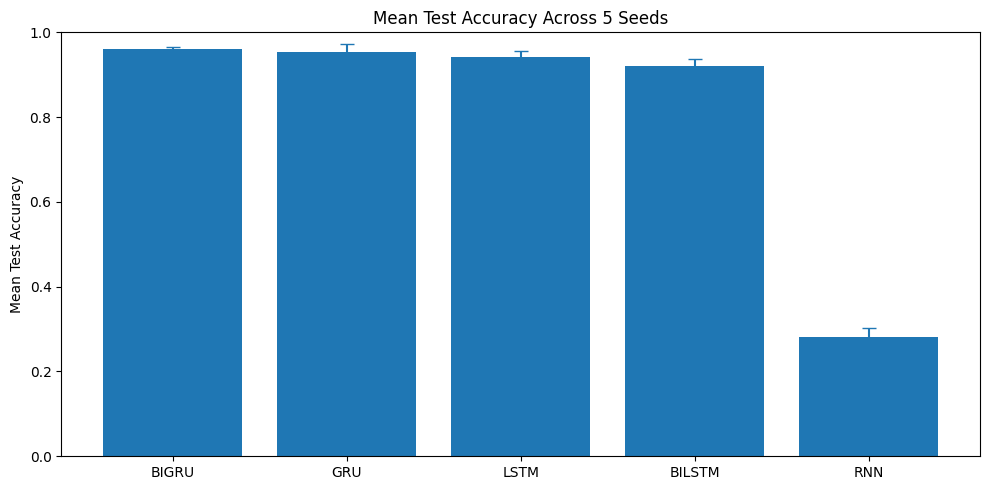

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(summary_df))
y = summary_df["test_acc_mean"].values
yerr = summary_df["test_acc_std"].fillna(0).values

plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)

plt.xticks(x, summary_df["architecture"].str.upper())
plt.ylabel("Mean Test Accuracy")
plt.title("Mean Test Accuracy Across 5 Seeds")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

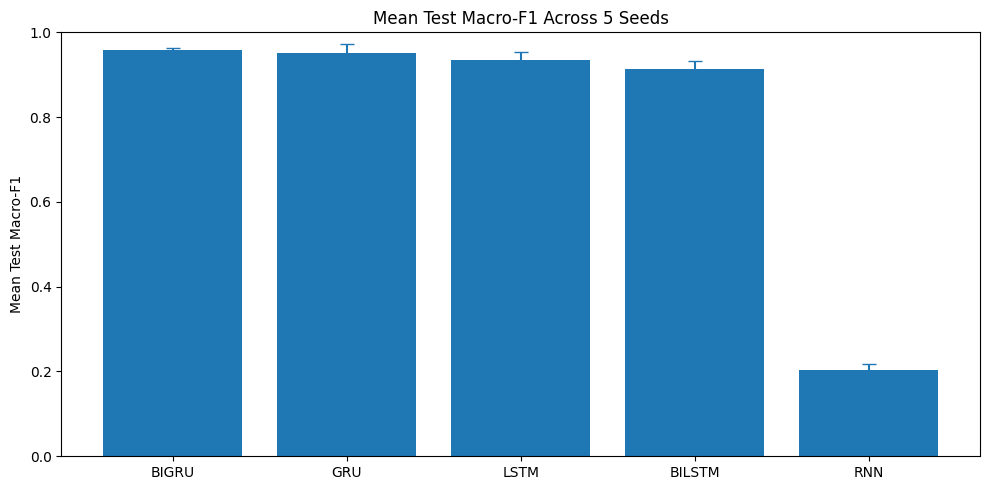

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(summary_df))
y = summary_df["test_macro_f1_mean"].values
yerr = summary_df["test_macro_f1_std"].fillna(0).values

plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)

plt.xticks(x, summary_df["architecture"].str.upper())
plt.ylabel("Mean Test Macro-F1")
plt.title("Mean Test Macro-F1 Across 5 Seeds")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
results_df.sort_values(["test_macro_f1", "test_acc"], ascending=False)

,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,bigru,13,15,0.957017,0.099565,0.965507,0.964228,0.964504,0.964367,332.702364
14,gru,3407,16,0.959568,0.119568,0.963169,0.962135,0.960778,0.964876,348.524083
12,gru,42,17,0.959371,0.115067,0.963461,0.961450,0.962971,0.960575,359.553994
3,bigru,123,18,0.965570,0.123994,0.963461,0.960844,0.959605,0.963260,389.961168
10,gru,13,14,0.961707,0.112812,0.961122,0.959401,0.961839,0.957498,308.717043
13,gru,123,15,0.963204,0.123341,0.961122,0.958692,0.962030,0.955831,326.551321
4,bigru,3407,12,0.953241,0.109942,0.960830,0.958130,0.956224,0.960861,278.506032
2,bigru,42,12,0.957682,0.115720,0.960538,0.955838,0.955734,0.956823,282.736959
19,lstm,3407,29,0.956591,0.142673,0.952645,0.949575,0.956933,0.943204,548.299751
1,bigru,27,9,0.947307,0.141196,0.950892,0.947583,0.951136,0.944597,227.964911


### Single Run Check

In [ ]:
best_runs_per_arch = (
    results_df
    .sort_values(["architecture", "test_macro_f1", "test_acc"], ascending=[True, False, False])
    .groupby("architecture", as_index=False)
    .first()
    .sort_values("architecture")
    .reset_index(drop=True)
)

print("Best seed for each architecture")
best_runs_per_arch

Best seed for each architecture


,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,bigru,13,15,0.957017,0.099565,0.965507,0.964228,0.964504,0.964367,332.702364
1,bilstm,13,19,0.947355,0.180960,0.939784,0.935471,0.934370,0.937339,418.002368
2,gru,3407,16,0.959568,0.119568,0.963169,0.962135,0.960778,0.964876,348.524083
3,lstm,3407,29,0.956591,0.142673,0.952645,0.949575,0.956933,0.943204,548.299751
4,rnn,13,5,0.220053,1.802494,0.315989,0.224824,0.238689,0.256388,138.031839


In [ ]:
summary_best_only = best_runs_per_arch[
    [
        "architecture",
        "seed",
        "best_epoch",
        "best_val_f1",
        "test_acc",
        "test_macro_f1",
        "test_macro_precision",
        "test_macro_recall",
        "train_time_sec"
    ]
].copy()

summary_best_only["architecture"] = summary_best_only["architecture"].str.upper()
summary_best_only

,architecture,seed,best_epoch,best_val_f1,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,BIGRU,13,15,0.957017,0.965507,0.964228,0.964504,0.964367,332.702364
1,BILSTM,13,19,0.947355,0.939784,0.935471,0.934370,0.937339,418.002368
2,GRU,3407,16,0.959568,0.963169,0.962135,0.960778,0.964876,348.524083
3,LSTM,3407,29,0.956591,0.952645,0.949575,0.956933,0.943204,548.299751
4,RNN,13,5,0.220053,0.315989,0.224824,0.238689,0.256388,138.031839


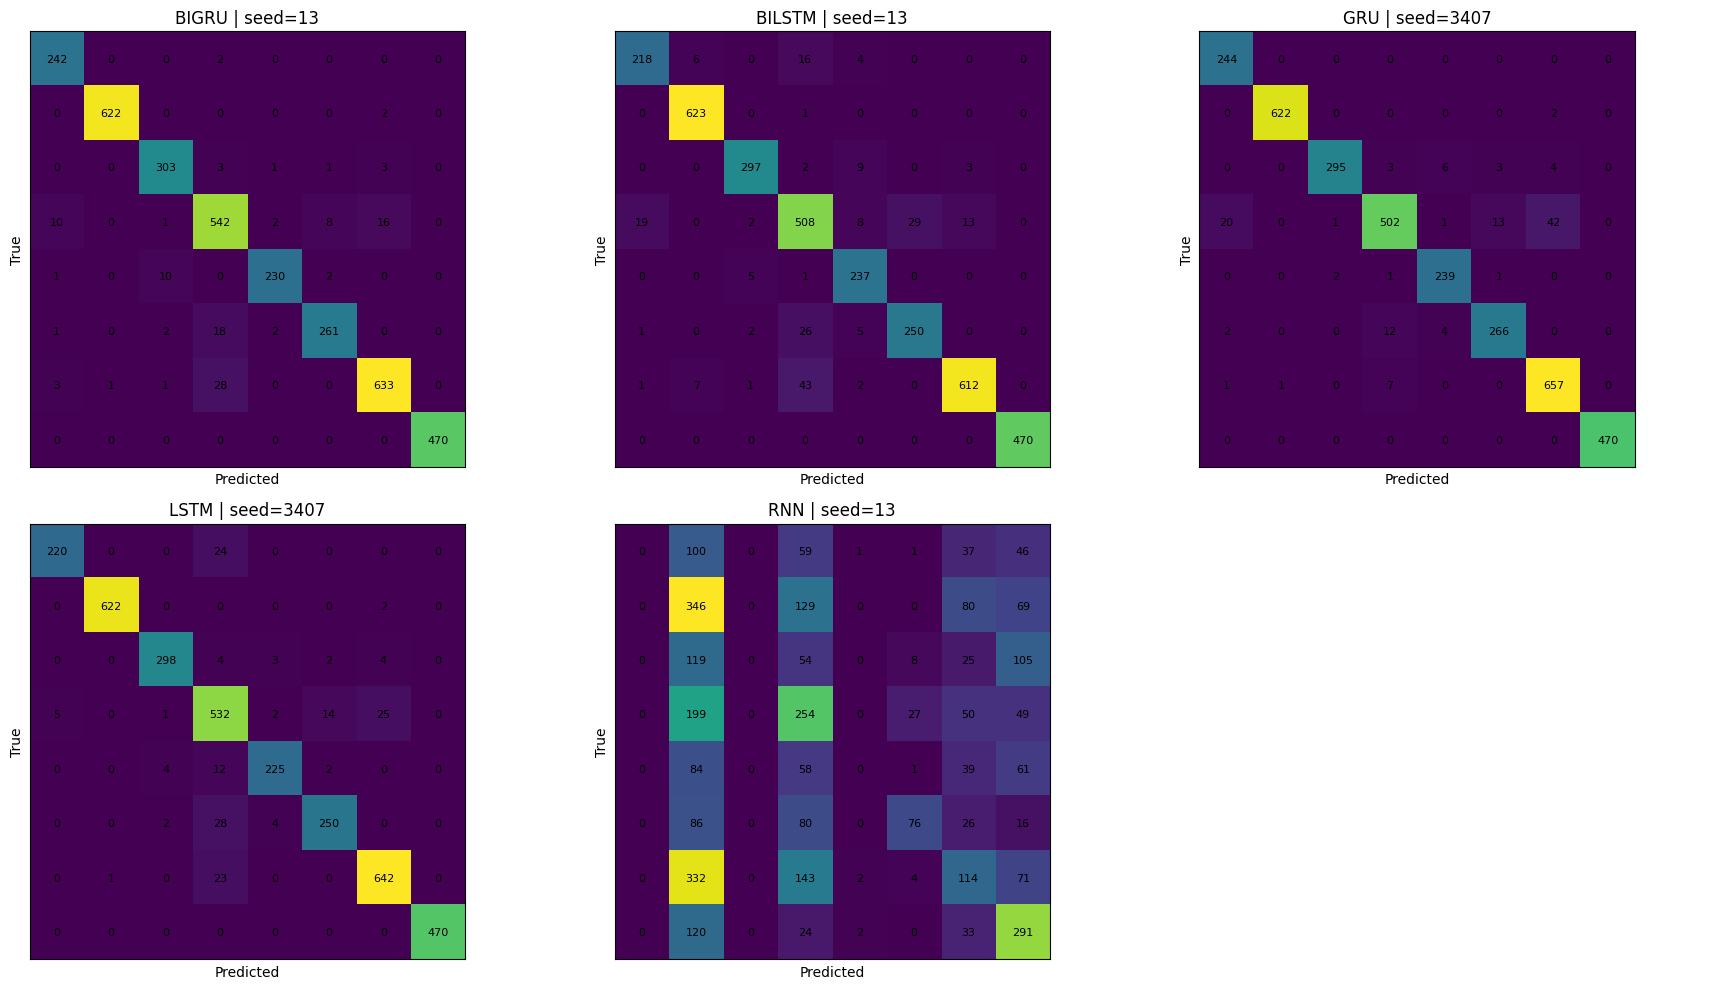

In [ ]:
import math

arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    output = all_outputs[(architecture, seed)]
    y_true = output["y_true"]
    y_pred = output["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    im = ax.imshow(cm)
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # ax.set_xticks(np.arange(len(label_names)))
    # ax.set_yticks(np.arange(len(label_names)))
    # ax.set_xticklabels([label_names[i] for i in range(len(label_names))], rotation=45, ha="right")
    # ax.set_yticklabels([label_names[i] for i in range(len(label_names))])

    ax.set_xticks([])
    ax.set_yticks([])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

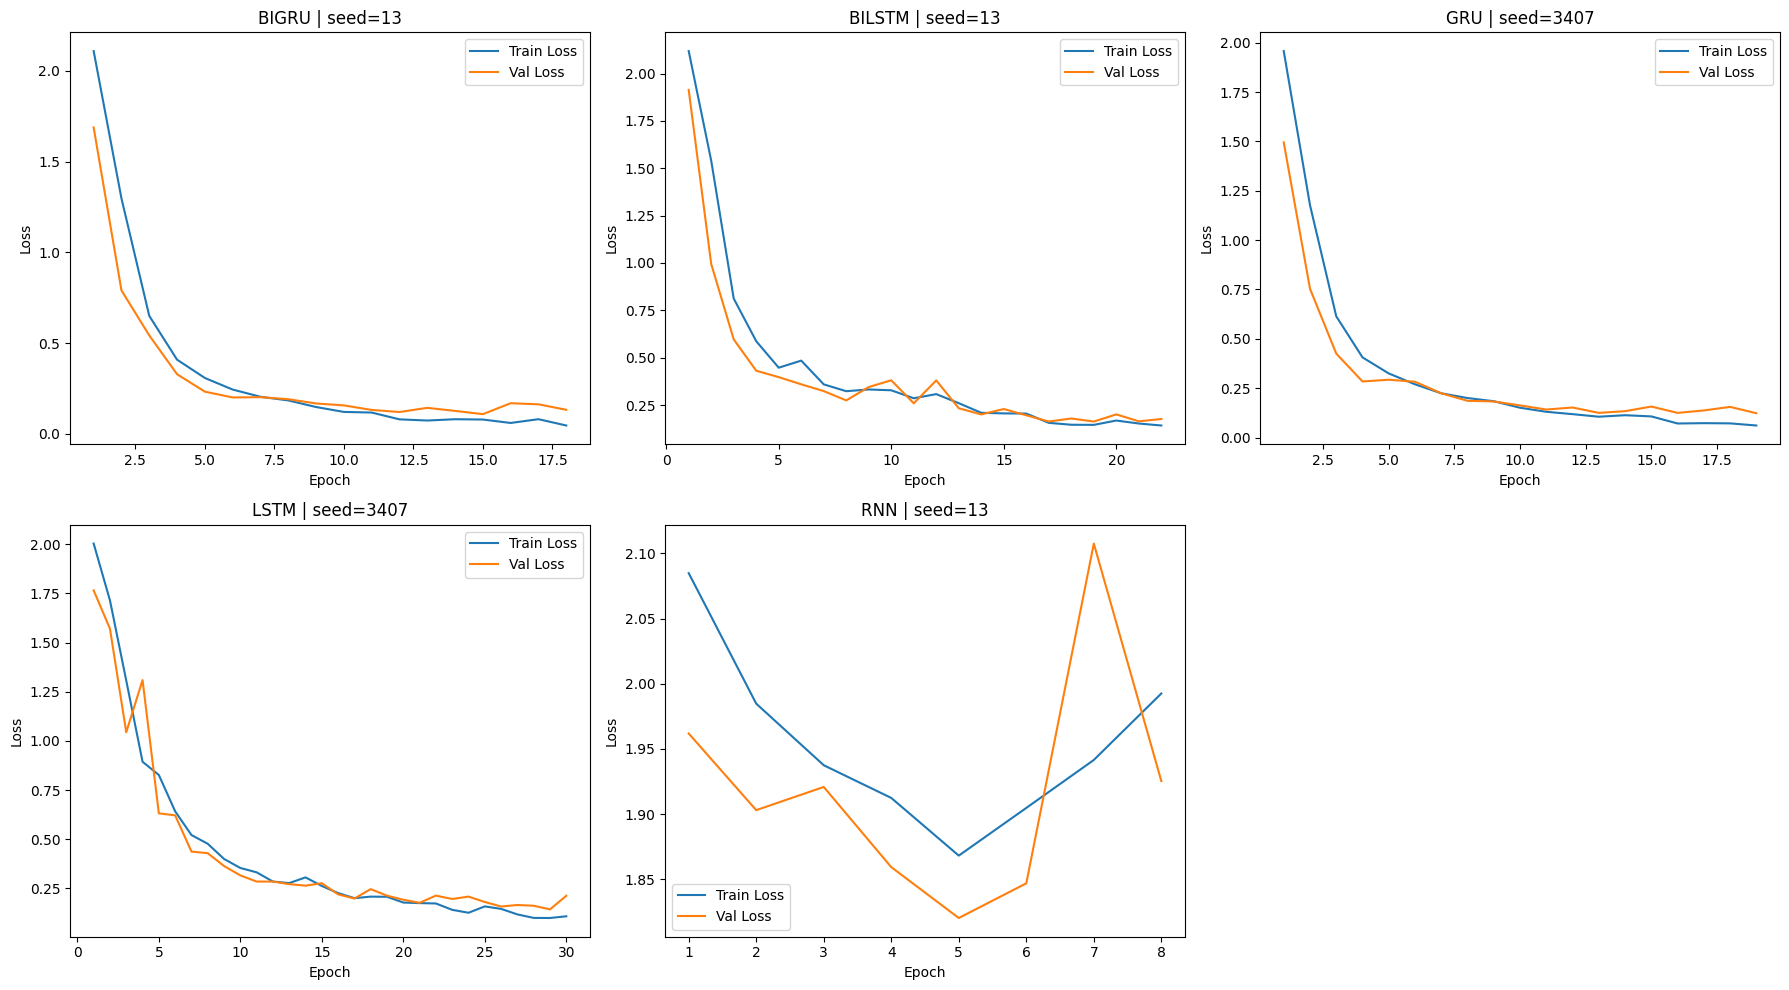

In [ ]:
arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    history = all_outputs[(architecture, seed)]["history"]

    ax.plot(history["epoch"], history["train_loss"], label="Train Loss")
    ax.plot(history["epoch"], history["val_loss"], label="Val Loss")
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

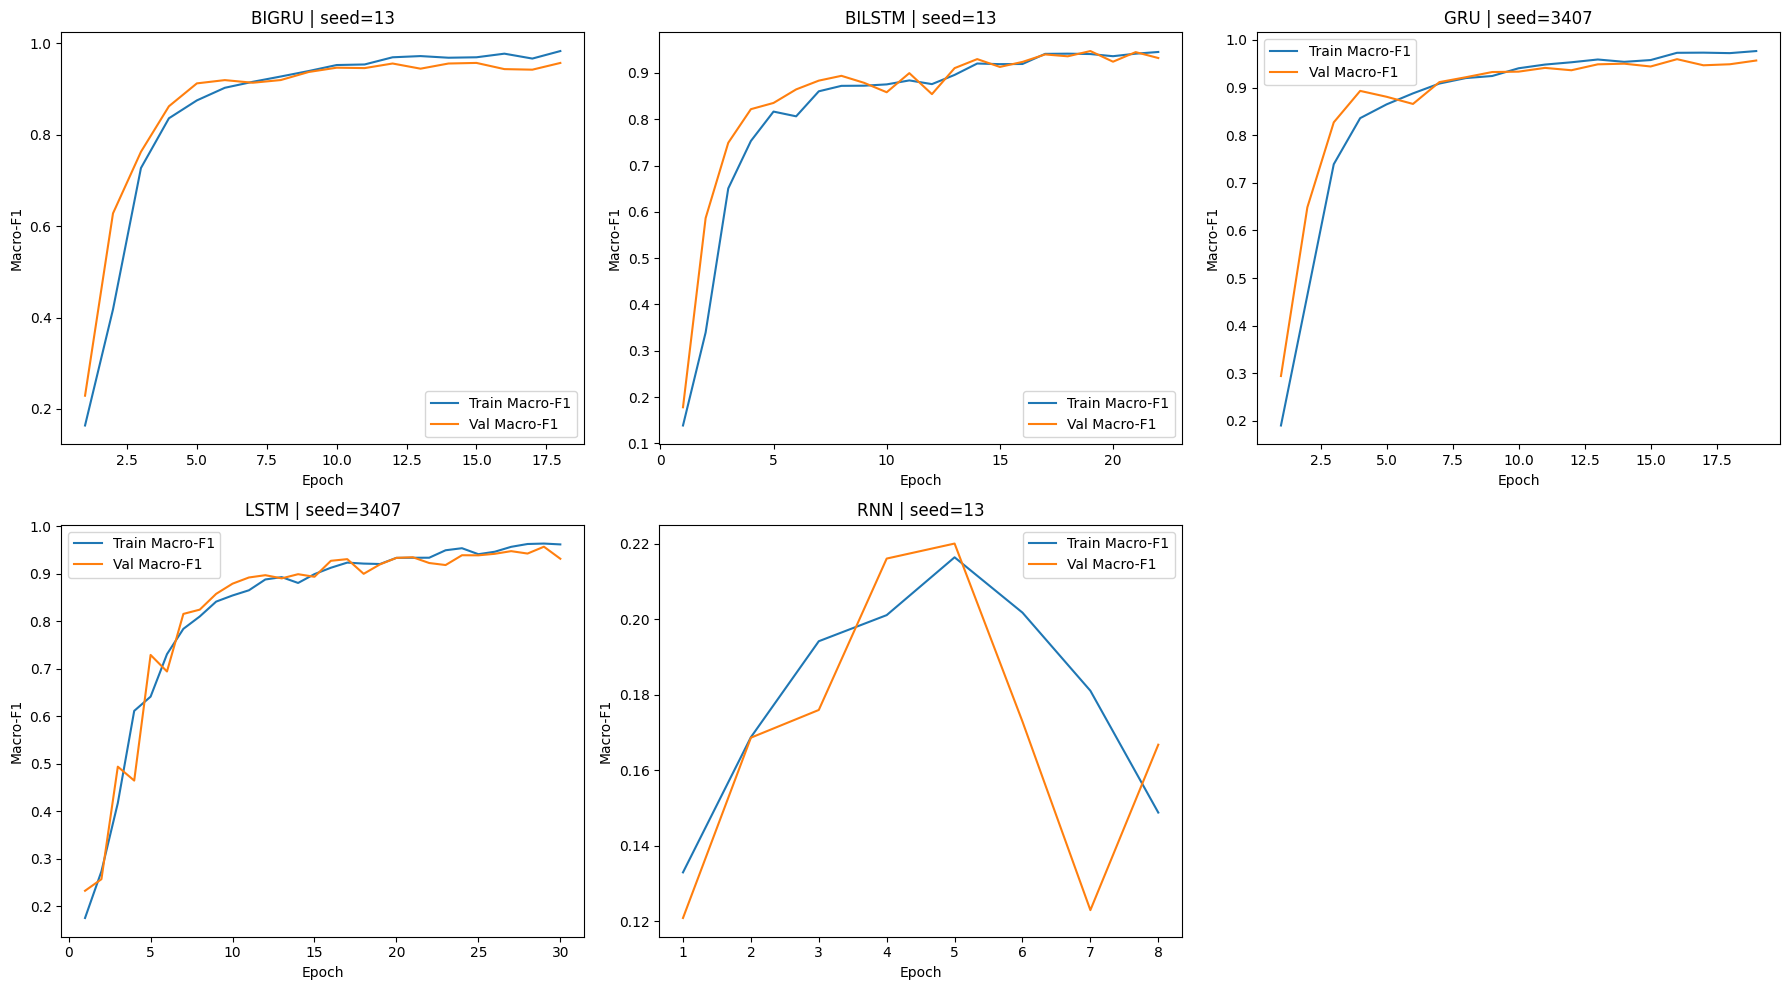

In [ ]:
arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    history = all_outputs[(architecture, seed)]["history"]

    ax.plot(history["epoch"], history["train_macro_f1"], label="Train Macro-F1")
    ax.plot(history["epoch"], history["val_macro_f1"], label="Val Macro-F1")
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro-F1")
    ax.legend()

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
best_visual_summary = best_runs_per_arch.copy()
best_visual_summary["architecture"] = best_visual_summary["architecture"].str.upper()

best_visual_summary = best_visual_summary[
    [
        "architecture",
        "seed",
        "best_epoch",
        "test_acc",
        "test_macro_f1",
        "test_macro_precision",
        "test_macro_recall"
    ]
].sort_values("test_macro_f1", ascending=False)

best_visual_summary

,architecture,seed,best_epoch,test_acc,test_macro_f1,test_macro_precision,test_macro_recall
0,BIGRU,13,15,0.965507,0.964228,0.964504,0.964367
2,GRU,3407,16,0.963169,0.962135,0.960778,0.964876
3,LSTM,3407,29,0.952645,0.949575,0.956933,0.943204
1,BILSTM,13,19,0.939784,0.935471,0.934370,0.937339
4,RNN,13,5,0.315989,0.224824,0.238689,0.256388


## Modelling and Training (w/ 2D Positional Encoding)

In [ ]:
num_classes = len(label_names)

patch_dim = 3 * patch_size * patch_size
embed_dim = 256
hidden_size = 256
num_layers = 3
recurrent_dropout = 0.3
head_dropout = 0.3

position_mode = "2d_learnable"

print("Patch dim   :", patch_dim)
print("Embed dim   :", embed_dim)
print("Hidden size :", hidden_size)
print("Num layers  :", num_layers)
print("Classes     :", num_classes)
print("Position mode :", position_mode)

Patch dim   : 768
Embed dim   : 256
Hidden size : 256
Num layers  : 3
Classes     : 8
Position mode : 2d_learnable


### Architecture Defined

In [ ]:
class RecurrentClassifier(nn.Module):
    def __init__(
        self,
        patch_dim: int,
        embed_dim: int,
        hidden_size: int,
        num_classes: int,
        architecture: str,
        grid_h: int,
        grid_w: int,
        num_layers: int = 2,
        recurrent_dropout: float = 0.0,
        head_dropout: float = 0.0,
        position_mode: str = "2d_learnable"
    ):
        super().__init__()

        self.architecture = architecture.lower()
        self.position_mode = position_mode
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.num_patches = grid_h * grid_w
        self.embed_dim = embed_dim

        # Patch projection
        self.patch_projection = nn.Linear(patch_dim, embed_dim)

        # Positional encoding
        if self.position_mode == "1d_learnable":
            self.pos_embedding = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
            self.row_embedding = None
            self.col_embedding = None

        elif self.position_mode == "2d_learnable":
            self.pos_embedding = None
            self.row_embedding = nn.Parameter(torch.zeros(1, grid_h, 1, embed_dim))
            self.col_embedding = nn.Parameter(torch.zeros(1, 1, grid_w, embed_dim))

        elif self.position_mode == "none":
            self.pos_embedding = None
            self.row_embedding = None
            self.col_embedding = None

        else:
            raise ValueError("position_mode must be one of: none, 1d_learnable, 2d_learnable")

        # Recurrent backbone
        if self.architecture == "rnn":
            self.bidirectional = False
            self.recurrent = nn.RNN(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False,
                nonlinearity="tanh"
            )

        elif self.architecture == "lstm":
            self.bidirectional = False
            self.recurrent = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False
            )

        elif self.architecture == "bilstm":
            self.bidirectional = True
            self.recurrent = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=True
            )

        elif self.architecture == "gru":
            self.bidirectional = False
            self.recurrent = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=False
            )

        elif self.architecture == "bigru":
            self.bidirectional = True
            self.recurrent = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout if num_layers > 1 else 0.0,
                bidirectional=True
            )

        else:
            raise ValueError("architecture must be one of: rnn, lstm, bilstm, gru, bigru")

        direction_factor = 2 if self.bidirectional else 1
        final_dim = hidden_size * direction_factor

        self.norm = nn.LayerNorm(final_dim)
        self.dropout = nn.Dropout(head_dropout)
        self.classifier = nn.Linear(final_dim, num_classes)

    def forward(self, x):
        """
        x: [B, num_patches, patch_dim]
        """
        B = x.size(0)

        # [B, num_patches, embed_dim]
        x = self.patch_projection(x)

        # Add positional encoding
        if self.position_mode == "1d_learnable":
            x = x + self.pos_embedding

        elif self.position_mode == "2d_learnable":
            # reshape token sequence -> 2D patch grid
            x = x.view(B, self.grid_h, self.grid_w, self.embed_dim)

            # row + col -> full 2D positional grid
            pos_2d = self.row_embedding + self.col_embedding   # [1, H, W, D]

            # add 2D PE
            x = x + pos_2d

            # flatten back to sequence
            x = x.view(B, self.num_patches, self.embed_dim)

        if self.architecture in ["lstm", "bilstm"]:
            output, (h_n, c_n) = self.recurrent(x)
        else:
            output, h_n = self.recurrent(x)

        if self.bidirectional:
            last_forward = h_n[-2]
            last_backward = h_n[-1]
            final_feature = torch.cat([last_forward, last_backward], dim=1)
        else:
            final_feature = h_n[-1]

        final_feature = self.norm(final_feature)
        final_feature = self.dropout(final_feature)
        logits = self.classifier(final_feature)

        return logits

In [ ]:
def build_model(architecture: str):
    model = RecurrentClassifier(
        patch_dim=patch_dim,
        embed_dim=embed_dim,
        hidden_size=hidden_size,
        num_classes=num_classes,
        architecture=architecture,
        grid_h=grid_h,
        grid_w=grid_w,
        num_layers=num_layers,
        recurrent_dropout=recurrent_dropout,
        head_dropout=head_dropout,
        position_mode=position_mode
    )
    return model.to(device)

### Training

In [ ]:
max_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4
early_stopping_patience = 3

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            seq = image_to_patch_sequence(images, patch_size=patch_size)
            logits = model(seq)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_f1

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            seq = image_to_patch_sequence(images, patch_size=patch_size)
            logits = model(seq)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "macro_f1": epoch_f1,
        "macro_precision": epoch_precision,
        "macro_recall": epoch_recall,
        "y_true": all_targets,
        "y_pred": all_preds
    }

In [ ]:
def fit_one_seed(architecture: str, seed: int):
    seed_everything(seed)

    train_loader, val_loader, test_loader = create_dataloaders(seed=seed)

    model = build_model(architecture=architecture)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    patience_counter = 0

    history = []

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler
        )

        val_metrics = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_macro_f1": val_metrics["macro_f1"]
        }
        history.append(row)

        print(
            f"[INFO] [{architecture.upper()} | seed={seed} | epoch={epoch:02d}] "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | train_f1={train_f1:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | val_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"[STOP] Early stopping triggered for {architecture} with seed {seed}.")
            break

    total_train_time = time.time() - start_time

    model.load_state_dict(best_state)

    test_metrics = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion
    )

    result = {
        "architecture": architecture,
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "train_time_sec": total_train_time
    }

    history_df = pd.DataFrame(history)

    output_bundle = {
        "y_true": test_metrics["y_true"],
        "y_pred": test_metrics["y_pred"],
        "history": history_df
    }

    return result, output_bundle

In [ ]:
architectures = ["rnn", "lstm", "bilstm", "gru", "bigru"]
seeds = [13, 27, 42, 123, 3407]

print("Architectures :", architectures)
print("Seeds         :", seeds)
print("Total runs    :", len(architectures) * len(seeds))

Architectures : ['rnn', 'lstm', 'bilstm', 'gru', 'bigru']
Seeds         : [13, 27, 42, 123, 3407]
Total runs    : 25


In [ ]:
all_results = []
all_outputs = {}

for architecture in architectures:
    print("\n" + "=" * 80)
    print(f"Running architecture: {architecture.upper()}")
    print("=" * 80)

    for seed in seeds:
        result, output_bundle = fit_one_seed(architecture=architecture, seed=seed)

        all_results.append(result)
        all_outputs[(architecture, seed)] = output_bundle
        print(f"[INFO] SEED {seed} DONE.")


Running architecture: RNN
[INFO] [RNN | seed=13 | epoch=01] train_loss=2.0850 | train_acc=0.1880 | train_f1=0.1333 | val_loss=1.9630 | val_acc=0.2056 | val_f1=0.1154
[INFO] [RNN | seed=13 | epoch=02] train_loss=1.9876 | train_acc=0.2225 | train_f1=0.1668 | val_loss=1.9118 | val_acc=0.2588 | val_f1=0.1623
[INFO] [RNN | seed=13 | epoch=03] train_loss=1.9328 | train_acc=0.2612 | train_f1=0.1957 | val_loss=1.9167 | val_acc=0.2640 | val_f1=0.1840
[INFO] [RNN | seed=13 | epoch=04] train_loss=1.9659 | train_acc=0.2485 | train_f1=0.1858 | val_loss=2.0350 | val_acc=0.1898 | val_f1=0.1092
[INFO] [RNN | seed=13 | epoch=05] train_loss=1.9459 | train_acc=0.2472 | train_f1=0.1714 | val_loss=1.9035 | val_acc=0.2640 | val_f1=0.1861
[INFO] [RNN | seed=13 | epoch=06] train_loss=1.9278 | train_acc=0.2607 | train_f1=0.1879 | val_loss=1.8858 | val_acc=0.2699 | val_f1=0.1959
[INFO] [RNN | seed=13 | epoch=07] train_loss=1.8702 | train_acc=0.2822 | train_f1=0.2096 | val_loss=1.8231 | val_acc=0.3008 | val_f1=

### Evaluation Result

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["architecture", "seed"]).reset_index(drop=True)

results_df

,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,bigru,13,13,0.961778,0.122775,0.953230,0.952630,0.953154,0.952779,314.967890
1,bigru,27,8,0.946050,0.155764,0.943291,0.938153,0.938440,0.938876,218.871297
2,bigru,42,13,0.963984,0.104896,0.964923,0.962330,0.963418,0.961325,314.731177
3,bigru,123,13,0.967428,0.097860,0.967846,0.967923,0.970504,0.965609,319.737287
4,bigru,3407,12,0.963722,0.106641,0.963753,0.960963,0.959885,0.962370,296.809934
5,bilstm,13,11,0.914640,0.229201,0.921368,0.912332,0.914952,0.912496,279.905470
6,bilstm,27,17,0.937298,0.200741,0.931599,0.924320,0.933240,0.918121,395.693880
7,bilstm,42,26,0.944151,0.174981,0.944461,0.940336,0.940959,0.940272,572.707201
8,bilstm,123,16,0.933938,0.190073,0.933061,0.928498,0.926493,0.930832,379.680937
9,bilstm,3407,17,0.934284,0.190839,0.933061,0.923927,0.926845,0.923307,401.403596


In [ ]:
summary_df = (
    results_df
    .groupby("architecture", as_index=False)
    .agg(
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),
        test_precision_mean=("test_macro_precision", "mean"),
        test_precision_std=("test_macro_precision", "std"),
        test_recall_mean=("test_macro_recall", "mean"),
        test_recall_std=("test_macro_recall", "std"),
        best_val_f1_mean=("best_val_f1", "mean"),
        best_val_f1_std=("best_val_f1", "std"),
        train_time_mean_sec=("train_time_sec", "mean"),
        best_epoch_mean=("best_epoch", "mean")
    )
    .sort_values("test_macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

summary_df

,architecture,test_acc_mean,test_acc_std,test_macro_f1_mean,test_macro_f1_std,test_precision_mean,test_precision_std,test_recall_mean,test_recall_std,best_val_f1_mean,best_val_f1_std,train_time_mean_sec,best_epoch_mean
0,bigru,0.958609,0.010188,0.956400,0.011575,0.957080,0.012156,0.956192,0.010778,0.960592,0.008380,293.023517,11.8
1,gru,0.951125,0.011826,0.947196,0.014731,0.947808,0.011675,0.948319,0.017405,0.951611,0.010445,307.272208,13.0
2,bilstm,0.932710,0.008188,0.925883,0.010070,0.928498,0.009592,0.925005,0.010883,0.932862,0.010981,405.878217,17.4
3,lstm,0.913885,0.022795,0.907001,0.025570,0.909101,0.025789,0.906363,0.025317,0.909836,0.029748,331.863281,14.2
4,rnn,0.294358,0.019455,0.207646,0.016530,0.233091,0.051623,0.245163,0.020752,0.207712,0.016338,136.366056,4.4


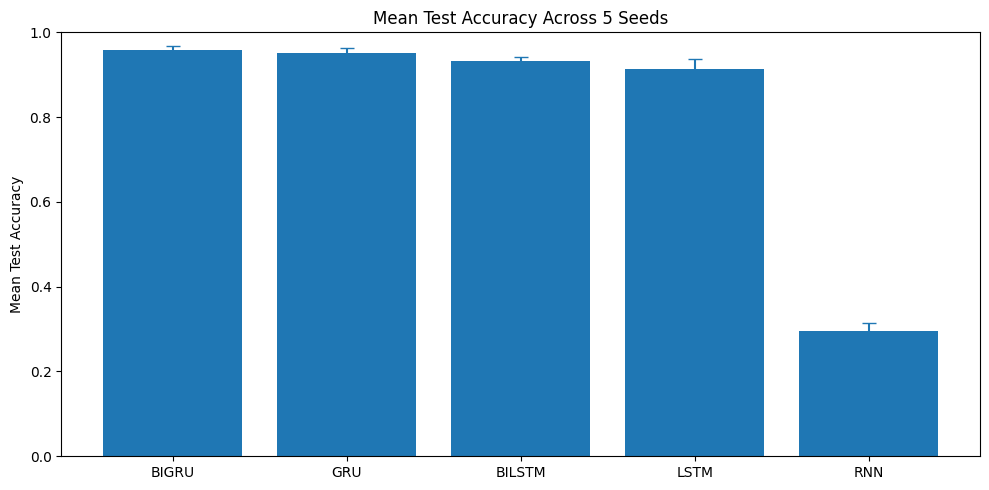

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(summary_df))
y = summary_df["test_acc_mean"].values
yerr = summary_df["test_acc_std"].fillna(0).values

plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)

plt.xticks(x, summary_df["architecture"].str.upper())
plt.ylabel("Mean Test Accuracy")
plt.title("Mean Test Accuracy Across 5 Seeds")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

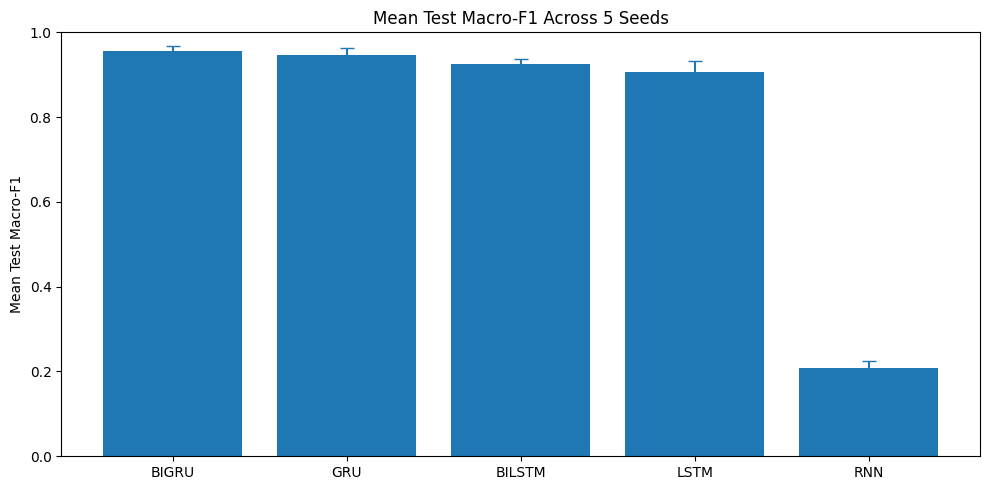

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(summary_df))
y = summary_df["test_macro_f1_mean"].values
yerr = summary_df["test_macro_f1_std"].fillna(0).values

plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)

plt.xticks(x, summary_df["architecture"].str.upper())
plt.ylabel("Mean Test Macro-F1")
plt.title("Mean Test Macro-F1 Across 5 Seeds")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
results_df.sort_values(["test_macro_f1", "test_acc"], ascending=False)

,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
3,bigru,123,13,0.967428,0.097860,0.967846,0.967923,0.970504,0.965609,319.737287
12,gru,42,19,0.965996,0.105331,0.964630,0.963186,0.961171,0.965741,422.520319
2,bigru,42,13,0.963984,0.104896,0.964923,0.962330,0.963418,0.961325,314.731177
4,bigru,3407,12,0.963722,0.106641,0.963753,0.960963,0.959885,0.962370,296.809934
13,gru,123,14,0.958839,0.108429,0.960830,0.960627,0.956894,0.965038,325.289876
0,bigru,13,13,0.961778,0.122775,0.953230,0.952630,0.953154,0.952779,314.967890
14,gru,3407,13,0.947006,0.134218,0.950892,0.946488,0.948763,0.945913,311.111721
7,bilstm,42,26,0.944151,0.174981,0.944461,0.940336,0.940959,0.940272,572.707201
19,lstm,3407,19,0.941543,0.186166,0.942414,0.938412,0.937663,0.939599,425.568096
1,bigru,27,8,0.946050,0.155764,0.943291,0.938153,0.938440,0.938876,218.871297


### Single Run Check

In [ ]:
best_runs_per_arch = (
    results_df
    .sort_values(["architecture", "test_macro_f1", "test_acc"], ascending=[True, False, False])
    .groupby("architecture", as_index=False)
    .first()
    .sort_values("architecture")
    .reset_index(drop=True)
)

print("Best seed for each architecture")
best_runs_per_arch

Best seed for each architecture


,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,bigru,123,13,0.967428,0.097860,0.967846,0.967923,0.970504,0.965609,319.737287
1,bilstm,42,26,0.944151,0.174981,0.944461,0.940336,0.940959,0.940272,572.707201
2,gru,42,19,0.965996,0.105331,0.964630,0.963186,0.961171,0.965741,422.520319
3,lstm,3407,19,0.941543,0.186166,0.942414,0.938412,0.937663,0.939599,425.568096
4,rnn,3407,4,0.228313,1.800540,0.319205,0.229021,0.221278,0.274874,129.918546


In [ ]:
summary_best_only = best_runs_per_arch[
    [
        "architecture",
        "seed",
        "best_epoch",
        "best_val_f1",
        "test_acc",
        "test_macro_f1",
        "test_macro_precision",
        "test_macro_recall",
        "train_time_sec"
    ]
].copy()

summary_best_only["architecture"] = summary_best_only["architecture"].str.upper()
summary_best_only

,architecture,seed,best_epoch,best_val_f1,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,BIGRU,123,13,0.967428,0.967846,0.967923,0.970504,0.965609,319.737287
1,BILSTM,42,26,0.944151,0.944461,0.940336,0.940959,0.940272,572.707201
2,GRU,42,19,0.965996,0.964630,0.963186,0.961171,0.965741,422.520319
3,LSTM,3407,19,0.941543,0.942414,0.938412,0.937663,0.939599,425.568096
4,RNN,3407,4,0.228313,0.319205,0.229021,0.221278,0.274874,129.918546


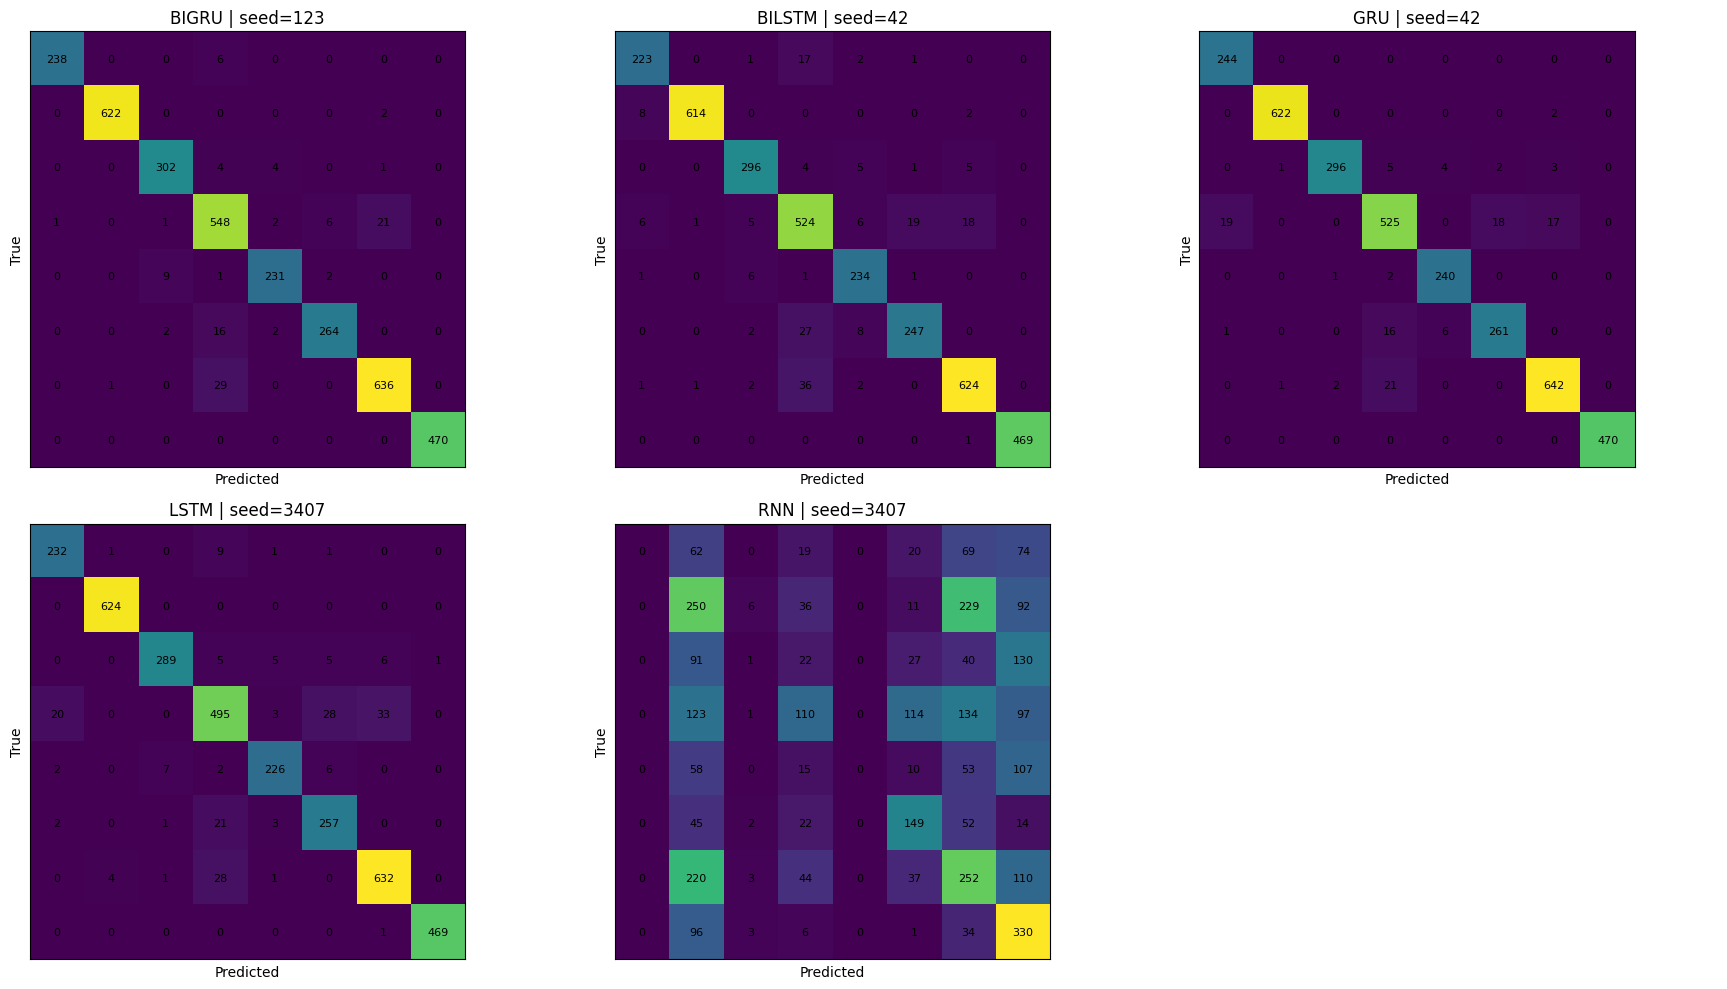

In [ ]:
import math

arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    output = all_outputs[(architecture, seed)]
    y_true = output["y_true"]
    y_pred = output["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    im = ax.imshow(cm)
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # ax.set_xticks(np.arange(len(label_names)))
    # ax.set_yticks(np.arange(len(label_names)))
    # ax.set_xticklabels([label_names[i] for i in range(len(label_names))], rotation=45, ha="right")
    # ax.set_yticklabels([label_names[i] for i in range(len(label_names))])

    ax.set_xticks([])
    ax.set_yticks([])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

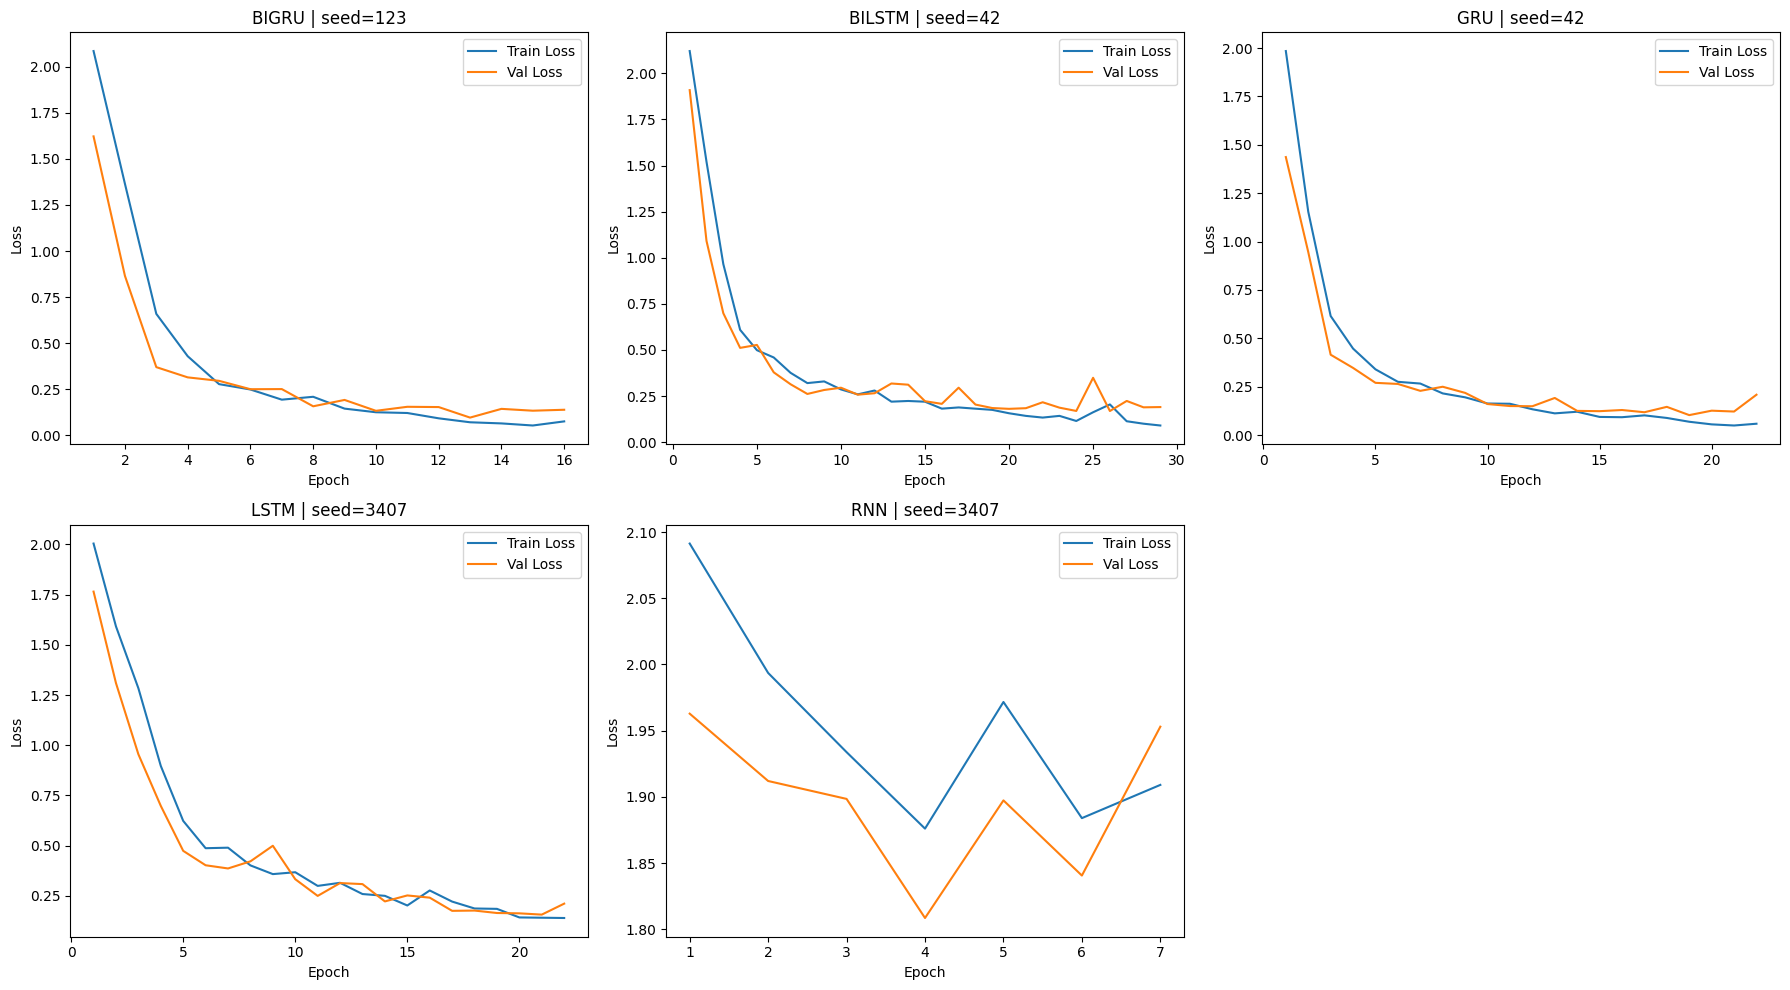

In [ ]:
arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    history = all_outputs[(architecture, seed)]["history"]

    ax.plot(history["epoch"], history["train_loss"], label="Train Loss")
    ax.plot(history["epoch"], history["val_loss"], label="Val Loss")
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

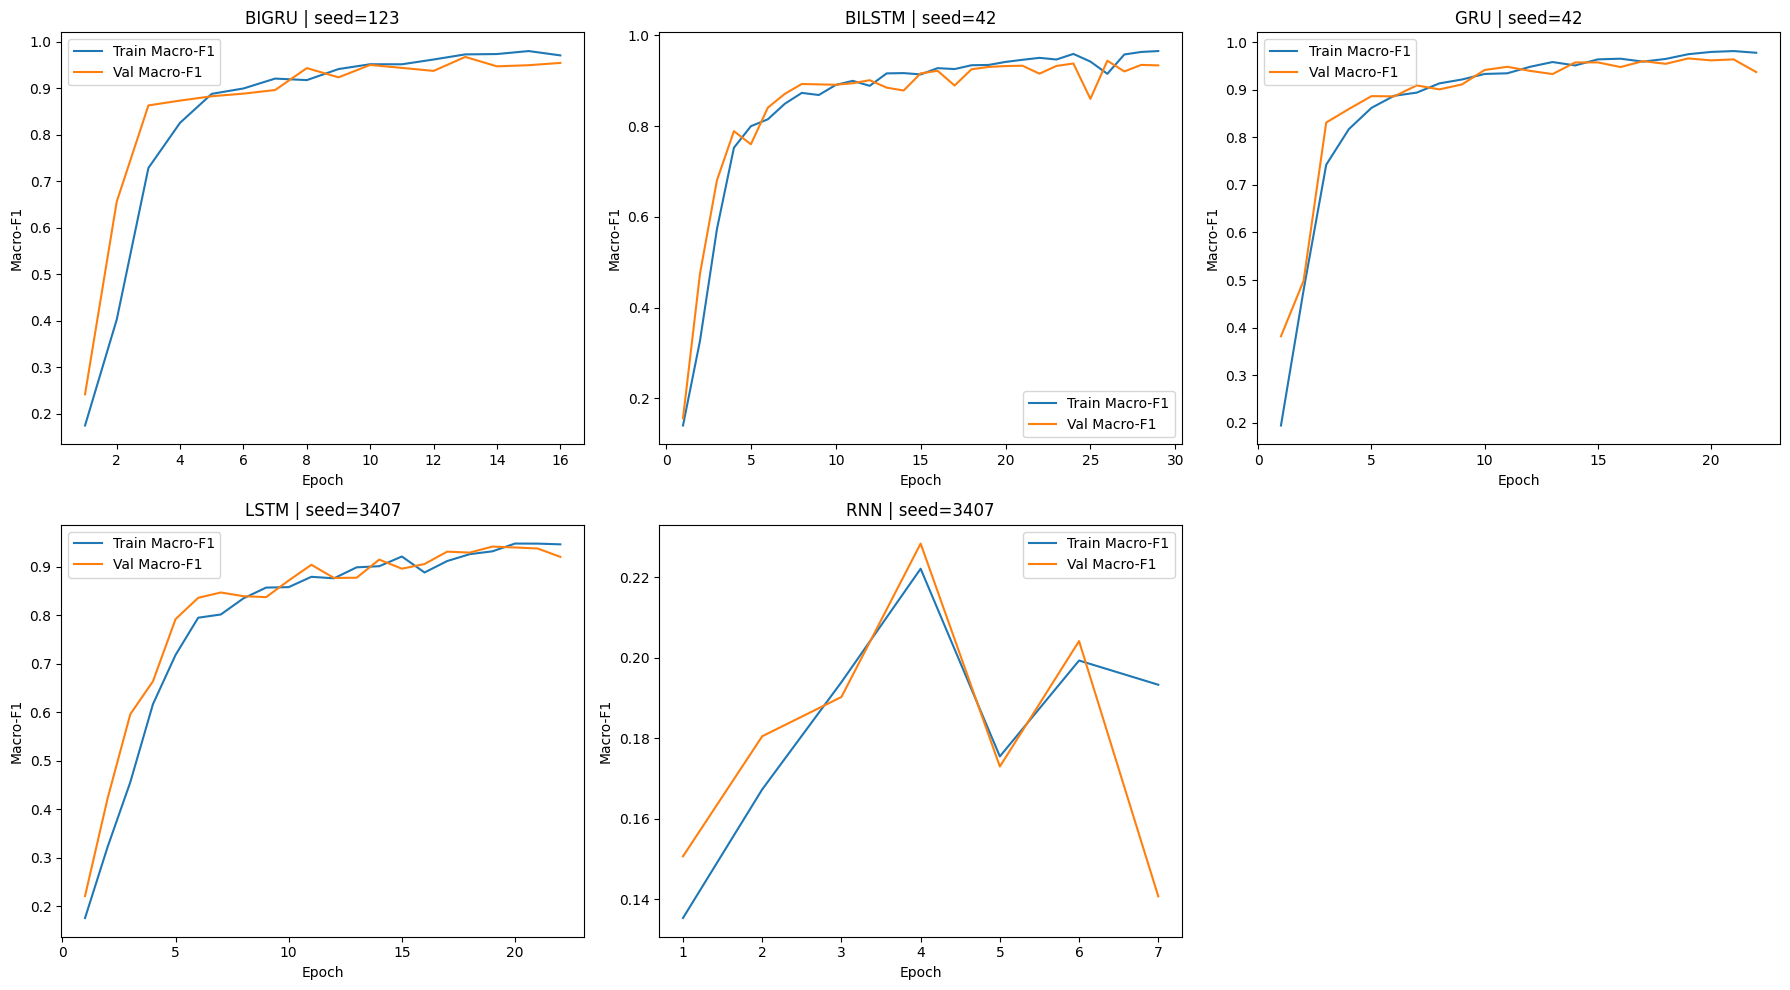

In [ ]:
arch_order = best_runs_per_arch["architecture"].tolist()

n_models = len(arch_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, best_runs_per_arch.iterrows()):
    architecture = row["architecture"]
    seed = int(row["seed"])

    history = all_outputs[(architecture, seed)]["history"]

    ax.plot(history["epoch"], history["train_macro_f1"], label="Train Macro-F1")
    ax.plot(history["epoch"], history["val_macro_f1"], label="Val Macro-F1")
    ax.set_title(f"{architecture.upper()} | seed={seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro-F1")
    ax.legend()

for k in range(n_models, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
best_visual_summary = best_runs_per_arch.copy()
best_visual_summary["architecture"] = best_visual_summary["architecture"].str.upper()

best_visual_summary = best_visual_summary[
    [
        "architecture",
        "seed",
        "best_epoch",
        "test_acc",
        "test_macro_f1",
        "test_macro_precision",
        "test_macro_recall"
    ]
].sort_values("test_macro_f1", ascending=False)

best_visual_summary

,architecture,seed,best_epoch,test_acc,test_macro_f1,test_macro_precision,test_macro_recall
0,BIGRU,123,13,0.967846,0.967923,0.970504,0.965609
2,GRU,42,19,0.964630,0.963186,0.961171,0.965741
1,BILSTM,42,26,0.944461,0.940336,0.940959,0.940272
3,LSTM,3407,19,0.942414,0.938412,0.937663,0.939599
4,RNN,3407,4,0.319205,0.229021,0.221278,0.274874


## CNN Based

In [ ]:
stats_transform = transforms.ToTensor()

train_dataset.transform = stats_transform
val_dataset.transform = stats_transform
test_dataset.transform = stats_transform

In [ ]:
stats_batch_size = 32
stats_num_workers = 2

In [ ]:
stats_loader = DataLoader(
    train_dataset,
    batch_size=stats_batch_size,
    shuffle=False,
    num_workers=stats_num_workers,
    pin_memory=(device.type == "cuda")
)

In [ ]:
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images, _ in stats_loader:
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sq_sum += (images ** 2).sum(dim=(0, 2, 3))
    num_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / num_pixels
std = torch.sqrt(channel_sq_sum / num_pixels - mean ** 2)

print("Mean :", mean)
print("Std  :", std)

Mean : tensor([0.7961, 0.6596, 0.6964])
Std  : tensor([0.2265, 0.2598, 0.0962])


In [ ]:
final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_dataset.transform = final_transform
val_dataset.transform = final_transform
test_dataset.transform = final_transform

/tmp/ipykernel_6664/1126044402.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[idx].set_title(label_names[int(label)])


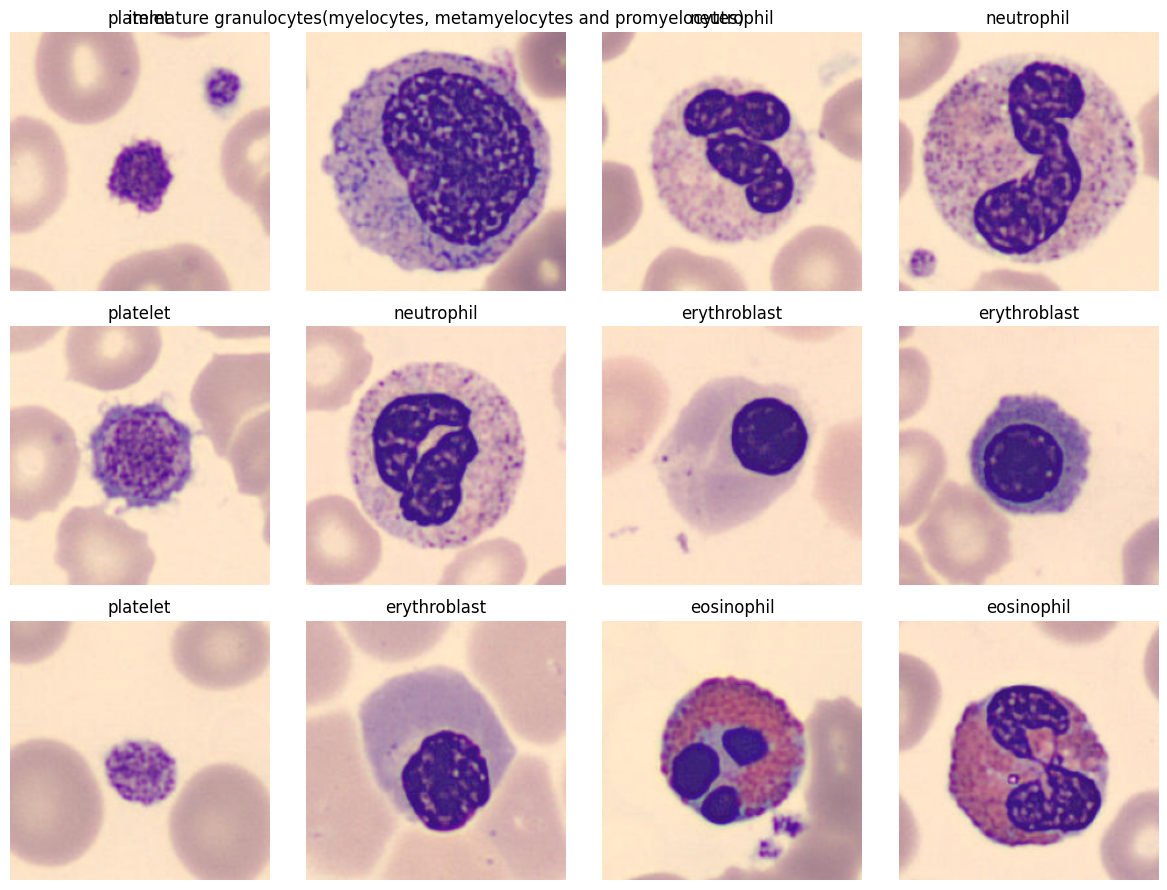

In [ ]:
num_preview_samples = 12

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for idx in range(num_preview_samples):
    image, label = train_dataset[idx]

    image = image.permute(1, 2, 0).cpu()
    image = image * std.view(1, 1, 3) + mean.view(1, 1, 3)
    image = torch.clamp(image, 0, 1)

    axes[idx].imshow(image.numpy())
    axes[idx].set_title(label_names[int(label)])
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    random.seed(worker_seed)
    np.random.seed(worker_seed)

In [ ]:
batch_size = 32
num_workers = 2

In [ ]:
def create_dataloaders(seed: int):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )

    return train_loader, val_loader, test_loader

In [ ]:
tmp_loader = DataLoader(train_dataset, batch_size=4, shuffle=False)
images, labels = next(iter(tmp_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Label dtype       :", labels.dtype)

Image batch shape : torch.Size([4, 3, 224, 224])
Label batch shape : torch.Size([4, 1])
Label dtype       : torch.int64


In [ ]:
num_classes = len(label_names)

base_channels = 32
dropout_rate = 0.30

print("Number of classes :", num_classes)
print("Base channels     :", base_channels)
print("Dropout rate      :", dropout_rate)

Number of classes : 8
Base channels     : 32
Dropout rate      : 0.3


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class BloodMNISTCNN(nn.Module):
    def __init__(self, num_classes: int, dropout_rate: float = 0.30):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(3, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [ ]:
def build_model():
    model = BloodMNISTCNN(
        num_classes=num_classes,
        dropout_rate=dropout_rate
    )
    return model.to(device)

In [ ]:
model = build_model()
print(model)

with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    logits = model(dummy)
    print("Output shape :", logits.shape)

BloodMNISTCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNor

In [ ]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 1,214,152


In [ ]:
max_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4
early_stopping_patience = 3

In [ ]:
criterion = nn.CrossEntropyLoss()
print(criterion)

CrossEntropyLoss()


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_f1

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.view(-1).long().to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "macro_f1": epoch_f1,
        "macro_precision": epoch_precision,
        "macro_recall": epoch_recall,
        "y_true": all_targets,
        "y_pred": all_preds
    }

In [ ]:
def fit_one_seed(seed: int):
    seed_everything(seed)

    train_loader, val_loader, test_loader = create_dataloaders(seed=seed)

    model = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler(device.type, enabled=use_amp)

    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    patience_counter = 0

    history = []

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler
        )

        val_metrics = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_macro_f1": val_metrics["macro_f1"]
        }
        history.append(row)

        print(
            f"[INFO] [CNN | seed={seed} | epoch={epoch:02d}] "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | train_f1={train_f1:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | val_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"[STOP] Early stopping triggered for seed {seed}.")
            break

    total_train_time = time.time() - start_time

    model.load_state_dict(best_state)

    test_metrics = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion
    )

    result = {
        "architecture": "cnn",
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "train_time_sec": total_train_time
    }

    output_bundle = {
        "history": pd.DataFrame(history),
        "y_true": test_metrics["y_true"],
        "y_pred": test_metrics["y_pred"]
    }

    return result, output_bundle

In [ ]:
seeds = [13, 27, 42, 123, 3407]
print("Seeds:", seeds)

Seeds: [13, 27, 42, 123, 3407]


In [ ]:
all_results = []
all_outputs = {}

for seed in seeds:
    print("\n" + "=" * 80)
    print(f"Running CNN with seed {seed}")
    print("=" * 80)

    result, output_bundle = fit_one_seed(seed=seed)

    all_results.append(result)
    all_outputs[seed] = output_bundle


Running CNN with seed 13
[INFO] [CNN | seed=13 | epoch=01] train_loss=0.5128 | train_acc=0.8270 | train_f1=0.7962 | val_loss=0.2598 | val_acc=0.9106 | val_f1=0.8953
[INFO] [CNN | seed=13 | epoch=02] train_loss=0.2807 | train_acc=0.9039 | train_f1=0.8940 | val_loss=0.3006 | val_acc=0.9124 | val_f1=0.9054
[INFO] [CNN | seed=13 | epoch=03] train_loss=0.2292 | train_acc=0.9227 | train_f1=0.9161 | val_loss=0.7326 | val_acc=0.7506 | val_f1=0.7284
[INFO] [CNN | seed=13 | epoch=04] train_loss=0.2054 | train_acc=0.9310 | train_f1=0.9260 | val_loss=0.1898 | val_acc=0.9340 | val_f1=0.9158
[INFO] [CNN | seed=13 | epoch=05] train_loss=0.1748 | train_acc=0.9406 | train_f1=0.9367 | val_loss=0.2849 | val_acc=0.9007 | val_f1=0.8931
[INFO] [CNN | seed=13 | epoch=06] train_loss=0.1610 | train_acc=0.9458 | train_f1=0.9427 | val_loss=0.2258 | val_acc=0.9206 | val_f1=0.9121
[INFO] [CNN | seed=13 | epoch=07] train_loss=0.1522 | train_acc=0.9487 | train_f1=0.9453 | val_loss=0.1099 | val_acc=0.9667 | val_f1=0

In [ ]:
results_df = pd.DataFrame(all_results).sort_values("seed").reset_index(drop=True)
results_df

,architecture,seed,best_epoch,best_val_f1,test_loss,test_acc,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,cnn,13,10,0.968172,0.089282,0.972815,0.973432,0.973876,0.973281,957.007035
1,cnn,27,8,0.960263,0.141954,0.956445,0.955086,0.958633,0.953299,813.310882
2,cnn,42,2,0.917492,0.212703,0.927214,0.915686,0.924038,0.915616,368.893933
3,cnn,123,9,0.975249,0.087091,0.974569,0.975517,0.975520,0.975674,890.591150
4,cnn,3407,6,0.971201,0.113415,0.964923,0.964787,0.967278,0.962845,668.452011


In [ ]:
summary_df = pd.DataFrame([{
    "architecture": "cnn",
    "test_acc_mean": results_df["test_acc"].mean(),
    "test_acc_std": results_df["test_acc"].std(),
    "test_macro_f1_mean": results_df["test_macro_f1"].mean(),
    "test_macro_f1_std": results_df["test_macro_f1"].std(),
    "test_precision_mean": results_df["test_macro_precision"].mean(),
    "test_precision_std": results_df["test_macro_precision"].std(),
    "test_recall_mean": results_df["test_macro_recall"].mean(),
    "test_recall_std": results_df["test_macro_recall"].std(),
    "best_val_f1_mean": results_df["best_val_f1"].mean(),
    "best_val_f1_std": results_df["best_val_f1"].std(),
    "best_epoch_mean": results_df["best_epoch"].mean(),
    "train_time_mean_sec": results_df["train_time_sec"].mean()
}])

summary_df

,architecture,test_acc_mean,test_acc_std,test_macro_f1_mean,test_macro_f1_std,test_precision_mean,test_precision_std,test_recall_mean,test_recall_std,best_val_f1_mean,best_val_f1_std,best_epoch_mean,train_time_mean_sec
0,cnn,0.959193,0.019268,0.956901,0.024413,0.959869,0.021103,0.956143,0.024345,0.958475,0.023559,7.0,739.651002


In [ ]:
row = summary_df.iloc[0]

print("CNN 5-seed summary")
print(f"Test Accuracy   : {row['test_acc_mean']:.4f} ± {row['test_acc_std']:.4f}")
print(f"Test Macro-F1   : {row['test_macro_f1_mean']:.4f} ± {row['test_macro_f1_std']:.4f}")
print(f"Test Precision  : {row['test_precision_mean']:.4f} ± {row['test_precision_std']:.4f}")
print(f"Test Recall     : {row['test_recall_mean']:.4f} ± {row['test_recall_std']:.4f}")
print(f"Best Val F1     : {row['best_val_f1_mean']:.4f} ± {row['best_val_f1_std']:.4f}")
print(f"Mean Best Epoch : {row['best_epoch_mean']:.2f}")
print(f"Mean Train Time : {row['train_time_mean_sec']:.2f} sec")

CNN 5-seed summary
Test Accuracy   : 0.9592 ± 0.0193
Test Macro-F1   : 0.9569 ± 0.0244
Test Precision  : 0.9599 ± 0.0211
Test Recall     : 0.9561 ± 0.0243
Best Val F1     : 0.9585 ± 0.0236
Mean Best Epoch : 7.00
Mean Train Time : 739.65 sec


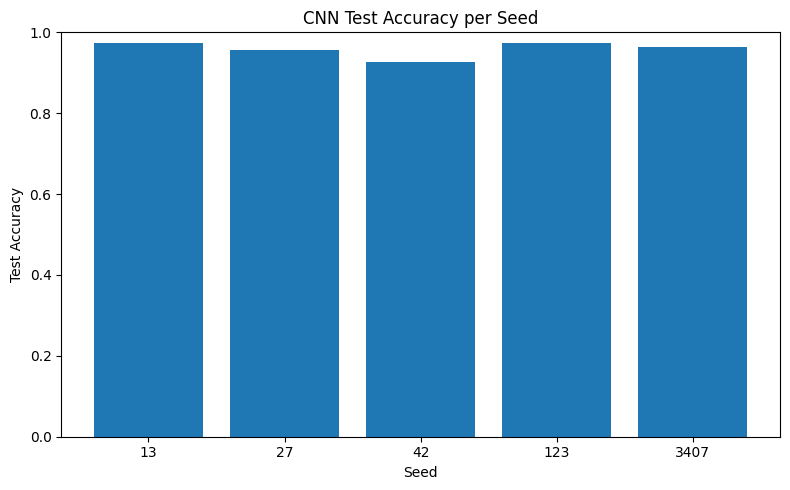

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["seed"].astype(str), results_df["test_acc"])
plt.ylabel("Test Accuracy")
plt.xlabel("Seed")
plt.title("CNN Test Accuracy per Seed")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

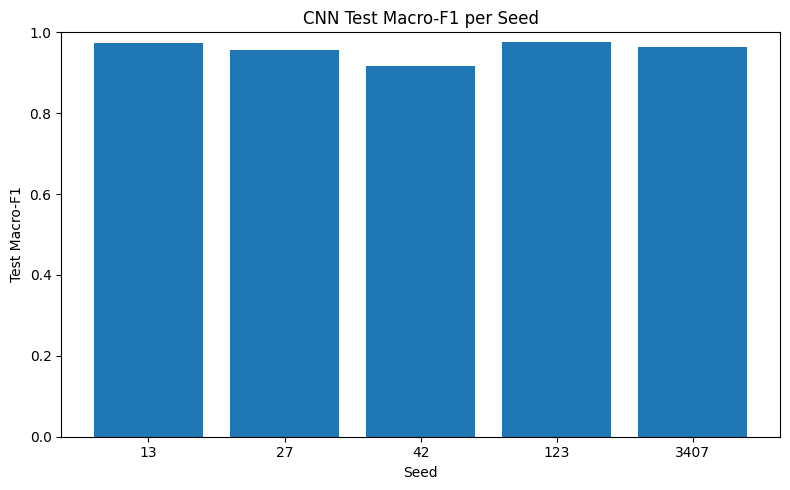

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["seed"].astype(str), results_df["test_macro_f1"])
plt.ylabel("Test Macro-F1")
plt.xlabel("Seed")
plt.title("CNN Test Macro-F1 per Seed")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
best_run = results_df.sort_values(
    ["test_macro_f1", "test_acc"],
    ascending=False
).iloc[0]

best_seed = int(best_run["seed"])

print("Best single run:")
print(best_run)

Best single run:
architecture                  cnn
seed                          123
best_epoch                      9
best_val_f1              0.975249
test_loss                0.087091
test_acc                 0.974569
test_macro_f1            0.975517
test_macro_precision      0.97552
test_macro_recall        0.975674
train_time_sec          890.59115
Name: 3, dtype: object


In [ ]:
best_output = all_outputs[best_seed]
best_history = best_output["history"]
y_true = best_output["y_true"]
y_pred = best_output["y_pred"]

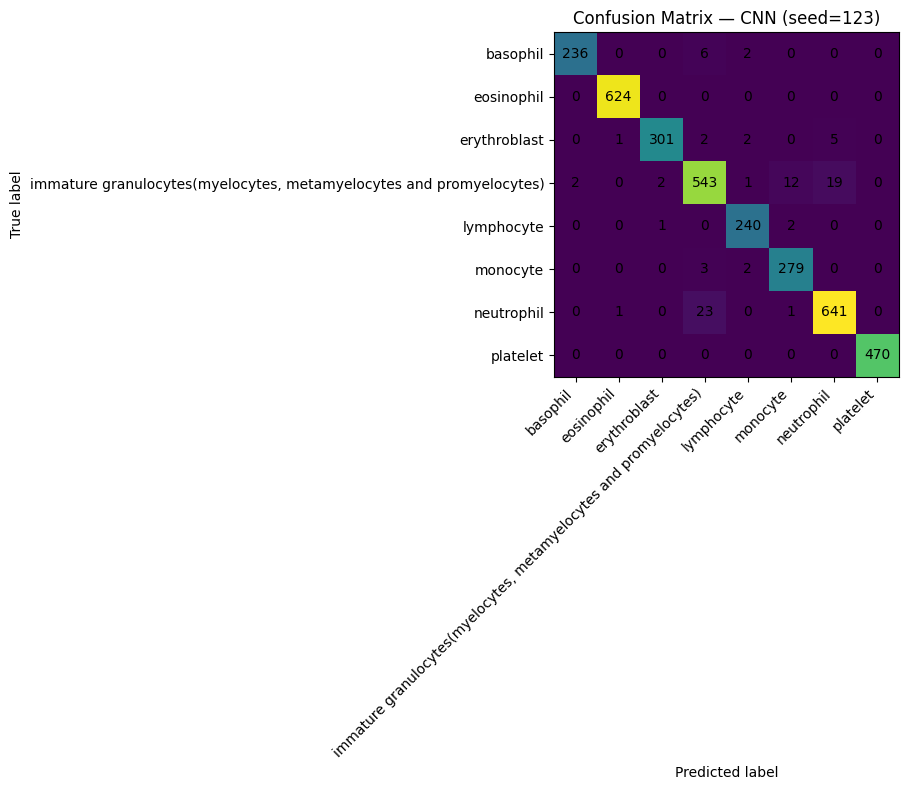

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(label_names)))
ax.set_yticks(np.arange(len(label_names)))
ax.set_xticklabels([label_names[i] for i in range(len(label_names))], rotation=45, ha="right")
ax.set_yticklabels([label_names[i] for i in range(len(label_names))])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

ax.set_title(f"Confusion Matrix — CNN (seed={best_seed})")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[label_names[i] for i in range(len(label_names))],
        digits=4,
        zero_division=0
    )
)

                                                                     precision    recall  f1-score   support

                                                           basophil     0.9916    0.9672    0.9793       244
                                                         eosinophil     0.9968    1.0000    0.9984       624
                                                       erythroblast     0.9901    0.9678    0.9789       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)     0.9411    0.9378    0.9394       579
                                                         lymphocyte     0.9717    0.9877    0.9796       243
                                                           monocyte     0.9490    0.9824    0.9654       284
                                                         neutrophil     0.9639    0.9625    0.9632       666
                                                           platelet     1.0000    1.0000    1.0000       470

                 

In [ ]:
best_history

,epoch,train_loss,train_acc,train_macro_f1,val_loss,val_acc,val_macro_f1
0,1,0.504122,0.832846,0.805880,0.379221,0.855724,0.835083
1,2,0.253778,0.916799,0.909195,0.704136,0.792056,0.705172
2,3,0.235811,0.920813,0.913907,0.219697,0.924065,0.912507
3,4,0.187672,0.934694,0.929867,0.450505,0.865654,0.809174
4,5,0.169494,0.943223,0.939041,0.256251,0.902453,0.889998
5,6,0.155054,0.947069,0.943171,0.086056,0.971379,0.970353
6,7,0.142944,0.950581,0.947841,0.173675,0.929322,0.915811
7,8,0.136758,0.954929,0.953184,0.186219,0.942173,0.936243
8,9,0.126147,0.955264,0.953180,0.080705,0.975467,0.975249
9,10,0.125438,0.956351,0.953480,0.129329,0.952103,0.952288


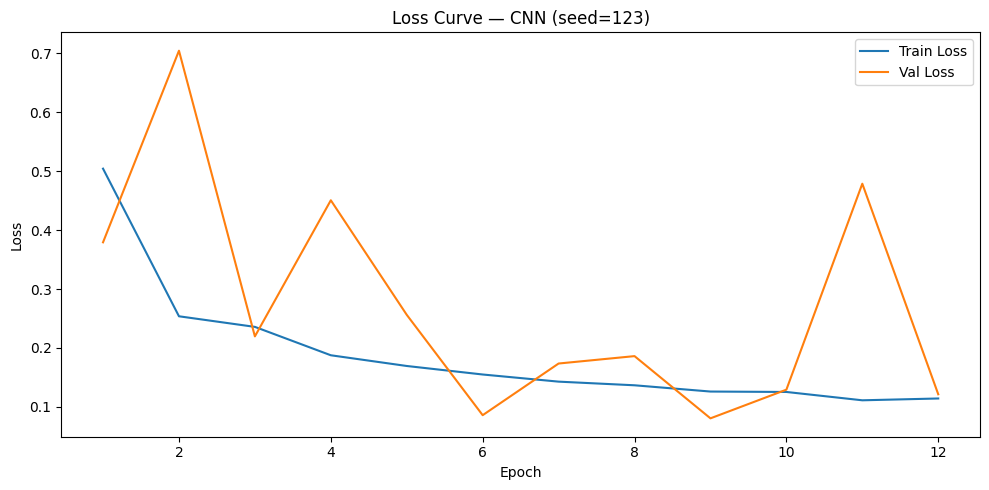

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(best_history["epoch"], best_history["train_loss"], label="Train Loss")
plt.plot(best_history["epoch"], best_history["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Curve — CNN (seed={best_seed})")
plt.legend()
plt.tight_layout()
plt.show()

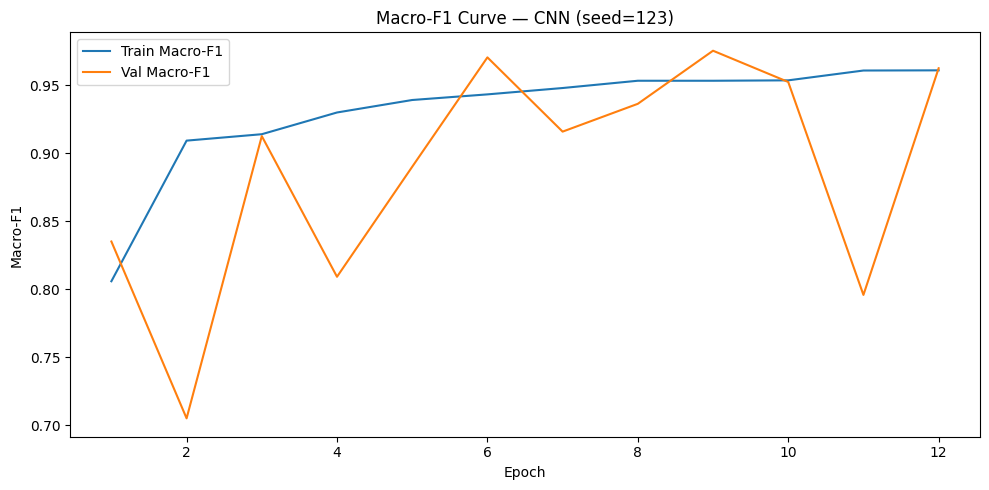

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(best_history["epoch"], best_history["train_macro_f1"], label="Train Macro-F1")
plt.plot(best_history["epoch"], best_history["val_macro_f1"], label="Val Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title(f"Macro-F1 Curve — CNN (seed={best_seed})")
plt.legend()
plt.tight_layout()
plt.show()